<a href="https://colab.research.google.com/github/B-Pearlraj/Driver_Drowsiness_DL/blob/main/Drowsiness_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1: Problem Understanding**

1. Problem Identification

Driver drowsiness is a major road-safety problem that can reduce a driver's alertness, reaction time, and decision-making ability.

The objective of this project is to develop a non-intrusive computer vision system that can identify early signs of driver fatigue from facial images.

2. Physiological Indicators

We use two important facial indicators:

👁️ Eye Closure → Detect whether the driver's eyes are Open or Closed.
😮 Yawning → Detect whether the driver is Yawning or Not Yawning.
3. Image Classification Problem

The system analyzes facial images and classifies them into four classes:

Class	Meaning
open	Eyes are open
closed	Eyes are closed
yawn	Driver is yawning
no_yawn	Driver is not yawning

These predictions will later be converted into three fatigue levels:

open + no_yawn  → Alert
yawn            → Mild Fatigue
closed          → Severe Fatigue

## **Step 2 — Dataset Collection**

In [1]:
import os

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train"

print("Dataset Path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset Path: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train
Exists: True


In [2]:
classes = os.listdir(DATASET_PATH)

print("Classes:")
for cls in classes:
    print(cls)

Classes:
Closed
yawn
no_yawn
Open
open
closed


In [3]:
from pathlib import Path

for cls in classes:
    class_path = Path(DATASET_PATH) / cls

    image_count = len([
        file for file in class_path.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])

    print(f"{cls}: {image_count} images")

Closed: 726 images
yawn: 723 images
no_yawn: 725 images
Open: 726 images
open: 0 images
closed: 0 images


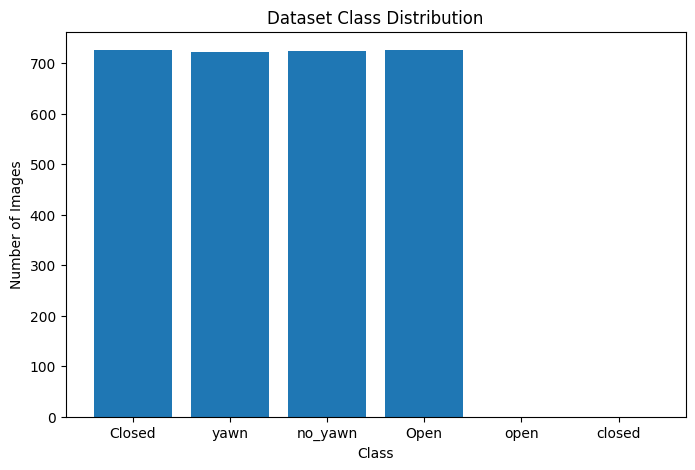

In [4]:
import matplotlib.pyplot as plt

class_counts = {}

for cls in classes:
    class_path = Path(DATASET_PATH) / cls

    count = len([
        file for file in class_path.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])

    class_counts[cls] = count

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.show()

## **Step 3: Dataset Organization**

In [5]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split



SOURCE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive/train"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive"
)

# Classes
CLASSES = ["open", "closed", "yawn", "no_yawn"]

# Split ratio
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print("Source Dataset:", SOURCE_DIR)
print("Output Dataset:", OUTPUT_DIR)

Source Dataset: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train
Output Dataset: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive


In [6]:
for split in ["train", "validation", "test"]:
    for cls in CLASSES:
        folder = OUTPUT_DIR / split / cls
        folder.mkdir(parents=True, exist_ok=True)

print("Folder structure created successfully.")

Folder structure created successfully.


In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for cls in CLASSES:

    class_source = SOURCE_DIR / cls

    images = [
        file for file in class_source.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"\nClass: {cls}")
    print(f"Total images: {len(images)}")

    # First split: 70% train, 30% temporary
    train_files, temp_files = train_test_split(
        images,
        test_size=(1 - TRAIN_RATIO),
        random_state=42
    )

    # Second split: 15% validation, 15% test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.5,
        random_state=42
    )

    # Copy files
    for file in train_files:
        shutil.copy2(
            file,
            OUTPUT_DIR / "train" / cls / file.name
        )

    for file in val_files:
        shutil.copy2(
            file,
            OUTPUT_DIR / "validation" / cls / file.name
        )

    for file in test_files:
        shutil.copy2(
            file,
            OUTPUT_DIR / "test" / cls / file.name
        )

    print(f"Train      : {len(train_files)}")
    print(f"Validation : {len(val_files)}")
    print(f"Test       : {len(test_files)}")

print("\nDataset splitting completed successfully!")


Class: open
Total images: 0


ValueError: With n_samples=0, test_size=0.30000000000000004 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [8]:
BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive"
)

print("Base path exists:", BASE_PATH.exists())
print("\nContents:\n")

for item in BASE_PATH.iterdir():
    print(item.name, "→", "Folder" if item.is_dir() else "File")

Base path exists: True

Contents:

train → Folder
validation → Folder
test → Folder
split_dataset → Folder


In [9]:
print("\nAll folders inside archive:\n")

for path in BASE_PATH.rglob("*"):
    if path.is_dir():
        print(path)


All folders inside archive:

/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/validation
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/test
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/yawn
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/no_yawn
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Open
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/open
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/closed
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/val

In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    path for path in BASE_PATH.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total image files found:", len(images))

print("\nFirst 20 images:")

for image in images[:20]:
    print(image)

Total image files found: 5800

First 20 images:
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_1.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_100.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_103.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_104.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_10.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_0.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_102.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_101.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed/_105.jpg
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_D

In [11]:
BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive"
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "validation", "test"]:

    print("\n" + "=" * 50)
    print(split.upper())
    print("=" * 50)

    split_path = BASE_PATH / split

    for class_folder in sorted(split_path.iterdir()):

        if class_folder.is_dir():

            count = len([
                file for file in class_folder.iterdir()
                if file.is_file()
                and file.suffix.lower() in IMAGE_EXTENSIONS
            ])

            print(f"{class_folder.name:10} : {count}")


TRAIN
Closed     : 726
Open       : 726
closed     : 0
no_yawn    : 725
open       : 0
yawn       : 723

VALIDATION
closed     : 0
no_yawn    : 0
open       : 0
yawn       : 0

TEST
closed     : 0
no_yawn    : 0
open       : 0
yawn       : 0


In [12]:
BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive"
)

SOURCE_PATH = BASE_PATH / "train"

# New output folder
OUTPUT_PATH = BASE_PATH / "split_dataset"

# Original class folders
CLASS_FOLDERS = {
    "closed": "Closed",
    "open": "Open",
    "yawn": "yawn",
    "no_yawn": "no_yawn"
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

print("Source:", SOURCE_PATH)
print("Output:", OUTPUT_PATH)

Source: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train
Output: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset


In [13]:
# CREATE FOLDER STRUCTURE


for split in ["train", "validation", "test"]:

    for class_name in CLASS_FOLDERS.keys():

        folder_path = OUTPUT_PATH / split / class_name
        folder_path.mkdir(parents=True, exist_ok=True)

print("Folder structure created successfully.")

Folder structure created successfully.


In [14]:
# SPLIT DATASET


for class_name, folder_name in CLASS_FOLDERS.items():

    source_folder = SOURCE_PATH / folder_name

    images = [
        file for file in source_folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"\nClass: {class_name}")
    print(f"Total images: {len(images)}")

    # 70% Training + 30% Temporary


    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )


    # 15% Validation + 15% Test


    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )


    # Copy Training Images


    for image in train_images:

        destination = (
            OUTPUT_PATH /
            "train" /
            class_name /
            image.name
        )

        shutil.copy2(image, destination)


    # Copy Validation Images


    for image in validation_images:

        destination = (
            OUTPUT_PATH /
            "validation" /
            class_name /
            image.name
        )

        shutil.copy2(image, destination)


    # Copy Test Images


    for image in test_images:

        destination = (
            OUTPUT_PATH /
            "test" /
            class_name /
            image.name
        )

        shutil.copy2(image, destination)

    print(f"Training    : {len(train_images)}")
    print(f"Validation  : {len(validation_images)}")
    print(f"Test        : {len(test_images)}")


Class: closed
Total images: 726
Training    : 508
Validation  : 109
Test        : 109

Class: open
Total images: 726
Training    : 508
Validation  : 109
Test        : 109

Class: yawn
Total images: 723
Training    : 506
Validation  : 108
Test        : 109

Class: no_yawn
Total images: 725
Training    : 507
Validation  : 109
Test        : 109


In [15]:
# VERIFY DATASET SPLIT
for split in ["train", "validation", "test"]:

    print("\n" + "=" * 50)
    print(split.upper())
    print("=" * 50)

    total = 0

    for class_name in CLASS_FOLDERS.keys():

        folder = OUTPUT_PATH / split / class_name

        count = len([
            file for file in folder.iterdir()
            if file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        ])

        total += count

        print(f"{class_name:10} : {count}")

    print("-" * 50)
    print(f"Total      : {total}")


TRAIN
closed     : 508
open       : 508
yawn       : 506
no_yawn    : 507
--------------------------------------------------
Total      : 2029

VALIDATION
closed     : 109
open       : 109
yawn       : 108
no_yawn    : 109
--------------------------------------------------
Total      : 435

TEST
closed     : 109
open       : 109
yawn       : 109
no_yawn    : 109
--------------------------------------------------
Total      : 436


## **Step 4: Data Preprocessing**

####We will use TensorFlow/Keras and prepare the images for both:

####Custom CNN
####MobileNetV2

### **4.1 Import Libraries**

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### **4.2 Define Dataset Paths**

In [17]:
BASE_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive/split_dataset"
)

TRAIN_PATH = BASE_PATH + "/train"
VAL_PATH = BASE_PATH + "/validation"
TEST_PATH = BASE_PATH + "/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Train Path:", TRAIN_PATH)
print("Validation Path:", VAL_PATH)
print("Test Path:", TEST_PATH)

Train Path: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train
Validation Path: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/validation
Test Path: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/test


### **4.3 Load Training Dataset**

In [18]:
train_ds = image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

Found 2029 files belonging to 4 classes.


### **4.4 Load Validation Dataset**

In [19]:
val_ds = image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 435 files belonging to 4 classes.


### **4.5 Load Test Dataset**

In [20]:
test_ds = image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 436 files belonging to 4 classes.


### **4.6 Check Class Names**

In [21]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['closed', 'no_yawn', 'open', 'yawn']
Number of classes: 4


### **4.7 Normalize Pixel Values**

In [22]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

### **4.8 Data Augmentation**

In [23]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(
        factor=0.10
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomBrightness(
        factor=0.15,
        value_range=(0, 1)
    ),

    tf.keras.layers.RandomFlip(
        mode="horizontal"
    )

], name="data_augmentation")

### **4.9 Create Preprocessing Pipeline**

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

# Training pipeline
train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(normalization_layer(x)),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

# Validation pipeline
val_ds = val_ds.map(
    lambda x, y: (
        normalization_layer(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

# Test pipeline
test_ds = test_ds.map(
    lambda x, y: (
        normalization_layer(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

### **4.10 Improve Performance**

In [25]:
train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

### **4.11 Check Image Shape**

In [26]:
for images, labels in train_ds.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 4)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### **4.12 Visualize Augmented Images**

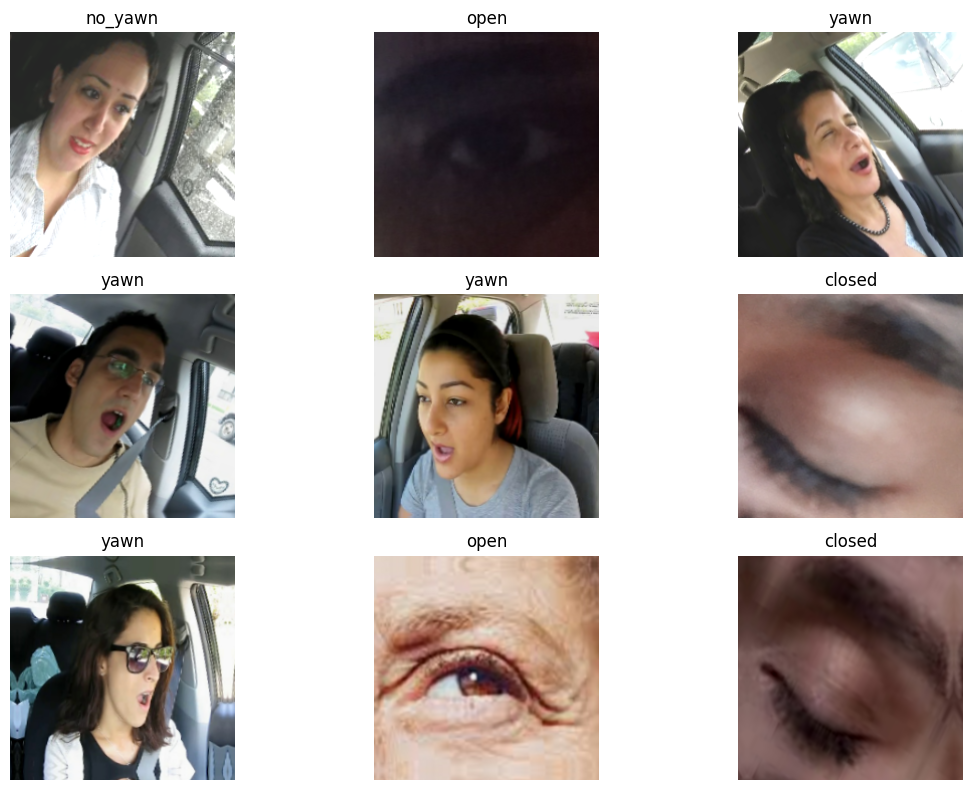

In [27]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy())

    label_index = tf.argmax(labels[i]).numpy()

    plt.title(class_names[label_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

# **Step 5: Model Selection**

**Markdown cell:**

Explain why Custom CNN is selected.
Explain why MobileNetV2 is selected.
Explain the comparison criteria:

*  Accuracy
*  Training time
*  Generalization

Small code cell:

In [28]:
print("TensorFlow Version:", tf.__version__)

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
NUM_CLASSES = 4

print("Input Shape:", (IMG_HEIGHT, IMG_WIDTH, CHANNELS))
print("Number of Classes:", NUM_CLASSES)

print("\nModels to be compared:")
print("1. Custom CNN")
print("2. MobileNetV2 Transfer Learning")

TensorFlow Version: 2.20.0
Input Shape: (224, 224, 3)
Number of Classes: 4

Models to be compared:
1. Custom CNN
2. MobileNetV2 Transfer Learning


In [29]:
# Check MobileNetV2 availability
from tensorflow.keras.applications import MobileNetV2

mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")
print("Total parameters:", mobilenet.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Total parameters: 2257984


we will build two different deep learning approaches and compare them:

Custom CNN
MobileNetV2 Transfer Learning

The important point is that we should not choose one model before testing both. The project requirement specifically asks us to analyze their performance.

###**5.1Model Comparison Strategy**
Feature	Custom CNN	MobileNetV2
Feature extraction	Learned from scratch	Pretrained ImageNet
Initial weights	Random	ImageNet pretrained
Training	Full network	Frozen base + classifier
Complexity	Lower	Higher architecture, but efficient
Dataset requirement	Usually needs more data	Works well with smaller datasets
Training time	We will measure	We will measure
Accuracy	We will measure	We will measure
Generalization	We will evaluate	We will evaluate

###**5.2 Common Input**

Both models will receive exactly the same preprocessed data:

224 × 224 × 3

and predict four classes:

closed
no_yawn
open
yawn

So the comparison will be fair.

###**5.3 Custom CNN Architecture**

Our Custom CNN will learn facial/eye/mouth features directly from your dataset.

**Architecture:**

Input: 224 × 224 × 3
        ↓
Conv2D
        ↓
MaxPooling
        ↓
Conv2D
        ↓
MaxPooling
        ↓
Conv2D
        ↓
MaxPooling
        ↓
Conv2D
        ↓
MaxPooling
        ↓
Flatten
        ↓
Dense
        ↓
Dropout
        ↓
4-Class Output

We will implement this in the next model-development step.

###**5.4 MobileNetV2 Architecture**

For MobileNetV2, we use the pretrained ImageNet feature extractor.

Input: 224 × 224 × 3
        ↓
MobileNetV2
ImageNet Weights
        ↓
Global Average Pooling
        ↓
Dense
        ↓
Dropout
        ↓
4-Class Output

Initially:

MobileNetV2 Base
       ↓
Frozen
       ↓
Train Classification Head

This follows your requirement to freeze the base layers during the initial training.

###**5.5 Important Correction for MobileNetV2**

There is one important preprocessing difference.

Our Step 4 normalized images to:

0 → 1

For the Custom CNN, that is perfectly suitable.

For MobileNetV2, however, we should use its preprocess_input function when feeding the model. MobileNetV2's preprocessing scales RGB pixel values appropriately for the pretrained ImageNet weights.

Therefore, when we implement the MobileNetV2 model, we should create its input preprocessing accordingly rather than simply assuming 0–1 normalization is identical to the ImageNet preprocessing.

###**5.6 What We Will Measure**

For each model, we will record:

**Accuracy**

Training Accuracy
Validation Accuracy
Test Accuracy

**Loss**

Training Loss
Validation Loss
Test Loss

**Training Time**

We will measure:

Start Time
    ↓
Model Training
    ↓
End Time
    ↓
Total Training Time

**Classification Performance**

We will later calculate:

Accuracy
Precision
Recall
F1-Score
Confusion Matrix

**Generalization**

We will compare:

Training Accuracy
        vs
Validation Accuracy
        vs
Test Accuracy

For example, if:

Training Accuracy = 99%
Validation Accuracy = 98%
Test Accuracy = 97%

the model is generalizing reasonably well.

But if:

Training Accuracy = 99%
Validation Accuracy = 82%
Test Accuracy = 78%

that indicates a possible overfitting problem.

# **Step 6: Model Development**

our dataset contains 4 classes, but Step 6 specifically asks for two independent models:

Eye State Model → Open vs Closed
Mouth State Model → Yawn vs No Yawn

We will build both Custom CNN and MobileNetV2 versions so that later we can compare them.

### **6.1 Load Libraries**

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [31]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### **6.2 Define Dataset Paths**

In [32]:
BASE_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/archive/split_dataset"
)

TRAIN_PATH = BASE_PATH + "/train"
VAL_PATH = BASE_PATH + "/validation"
TEST_PATH = BASE_PATH + "/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Dataset path:", BASE_PATH)

Dataset path: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset


### **6.3 Define Classes**

In [33]:
EYE_CLASSES = ["closed", "open"]

MOUTH_CLASSES = ["no_yawn", "yawn"]

print("Eye Classes:", EYE_CLASSES)
print("Mouth Classes:", MOUTH_CLASSES)

Eye Classes: ['closed', 'open']
Mouth Classes: ['no_yawn', 'yawn']


### **6.4 Create Eye Dataset**

In [34]:
def get_class_images(split_path, class_names):
    """
    Collect image paths and labels for selected classes.
    """

    image_paths = []
    labels = []

    for label, class_name in enumerate(class_names):

        class_path = os.path.join(split_path, class_name)

        for filename in os.listdir(class_path):

            file_path = os.path.join(class_path, filename)

            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                image_paths.append(file_path)
                labels.append(label)

    return image_paths, labels

In [35]:
eye_train_paths, eye_train_labels = get_class_images(
    TRAIN_PATH,
    EYE_CLASSES
)

eye_val_paths, eye_val_labels = get_class_images(
    VAL_PATH,
    EYE_CLASSES
)

eye_test_paths, eye_test_labels = get_class_images(
    TEST_PATH,
    EYE_CLASSES
)

print("Eye Training Images:", len(eye_train_paths))
print("Eye Validation Images:", len(eye_val_paths))
print("Eye Test Images:", len(eye_test_paths))

Eye Training Images: 1016
Eye Validation Images: 218
Eye Test Images: 218


### **6.5 Create Mouth Dataset**

In [36]:
mouth_train_paths, mouth_train_labels = get_class_images(
    TRAIN_PATH,
    MOUTH_CLASSES
)

mouth_val_paths, mouth_val_labels = get_class_images(
    VAL_PATH,
    MOUTH_CLASSES
)

mouth_test_paths, mouth_test_labels = get_class_images(
    TEST_PATH,
    MOUTH_CLASSES
)

print("Mouth Training Images:", len(mouth_train_paths))
print("Mouth Validation Images:", len(mouth_val_paths))
print("Mouth Test Images:", len(mouth_test_paths))

Mouth Training Images: 1013
Mouth Validation Images: 217
Mouth Test Images: 218


### **6.6 Image Loading Function**

In [37]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, tf.cast(label, tf.float32)

### **6.7 Create TensorFlow Dataset**

In [38]:
def create_dataset(image_paths, labels, shuffle=False):

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

### **6.8 Create Eye Datasets**

In [39]:
eye_train_ds = create_dataset(
    eye_train_paths,
    eye_train_labels,
    shuffle=True
)

eye_val_ds = create_dataset(
    eye_val_paths,
    eye_val_labels
)

eye_test_ds = create_dataset(
    eye_test_paths,
    eye_test_labels
)

### **6.9 Create Mouth Datasets**

In [40]:
mouth_train_ds = create_dataset(
    mouth_train_paths,
    mouth_train_labels,
    shuffle=True
)

mouth_val_ds = create_dataset(
    mouth_val_paths,
    mouth_val_labels
)

mouth_test_ds = create_dataset(
    mouth_test_paths,
    mouth_test_labels
)

### **6.10 Custom CNN — Eye Model**

In [41]:
def build_custom_cnn():

    model = models.Sequential([

        layers.Input(
            shape=(224, 224, 3)
        ),

        # Block 1
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        # Feature representation
        layers.Conv2D(
            256,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        # Classification head
        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

In [42]:
eye_custom_cnn = build_custom_cnn()

eye_custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### **6.11 Custom CNN — Mouth Model**

In [43]:
mouth_custom_cnn = build_custom_cnn()

mouth_custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### **6.12 MobileNetV2 — Eye Model**

In [44]:
def build_mobilenetv2():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    model = models.Sequential([

        layers.Input(
            shape=(224, 224, 3)
        ),

        # MobileNetV2 preprocessing
        layers.Lambda(
            preprocess_input
        ),

        # Pretrained feature extractor
        base_model,

        # Custom classification layers
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

In [45]:
eye_mobilenet = build_mobilenetv2()

eye_mobilenet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **6.13 MobileNetV2 — Mouth Model**

In [46]:
mouth_mobilenet = build_mobilenetv2()

mouth_mobilenet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Step 7: Model Training**

Here we will train the four models created in Step 6:

Custom CNN — Eye
MobileNetV2 — Eye
Custom CNN — Mouth
MobileNetV2 — Mouth

For both eye and mouth models, this is binary classification, so the appropriate loss function is:

Binary Crossentropy

and we will use:

Adam optimizer

In [47]:
LEARNING_RATE = 0.001

def compile_model(model):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [48]:
# Eye Models
eye_custom_cnn = compile_model(eye_custom_cnn)
eye_mobilenet = compile_model(eye_mobilenet)

# Mouth Models
mouth_custom_cnn = compile_model(mouth_custom_cnn)
mouth_mobilenet = compile_model(mouth_mobilenet)

print("All models compiled successfully.")

All models compiled successfully.


### **7.2 Verify MobileNetV2 is Frozen**

In [49]:
print(
    "Eye MobileNetV2 trainable:",
    eye_mobilenet.layers[1].trainable
)

print(
    "Mouth MobileNetV2 trainable:",
    mouth_mobilenet.layers[1].trainable
)

Eye MobileNetV2 trainable: False
Mouth MobileNetV2 trainable: False


The pretrained MobileNetV2 layers remain frozen, while the custom classification layers are trainable.

### **7.3 Training Configuration**

Because your dataset is relatively small, 15 epochs is a reasonable starting point. We will use EarlyStopping so training can stop automatically if validation performance stops improving.

In [50]:
EPOCHS = 15

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

### **7.4 Train Custom CNN — Eye Model**

In [51]:
import time

start_time = time.time()

eye_custom_history = eye_custom_cnn.fit(
    eye_train_ds,
    validation_data=eye_val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

eye_custom_training_time = time.time() - start_time

print(
    f"\nEye Custom CNN Training Time: "
    f"{eye_custom_training_time:.2f} seconds"
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 330ms/step - accuracy: 0.4882 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5226 - loss: 0.6931 - val_accuracy: 0.6697 - val_loss: 0.6881
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.5591 - loss: 0.6910 - val_accuracy: 0.6422 - val_loss: 0.6815
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.6368 - loss: 0.6773 - val_accuracy: 0.6789 - val_loss: 0.6358
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7195 - loss: 0.6019 - val_accuracy: 0.7569 - val_loss: 0.5339
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.7963 - loss: 0.4713 - val_accuracy: 0.8394 - val_loss: 0.4779
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.8465 - loss: 0.3948 - val_accuracy: 0.7661 - val_loss: 0.5610
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8396 - loss: 0.4152 - val_accuracy: 0.7844

### **7.5 Train MobileNetV2 — Eye Model**

In [52]:
start_time = time.time()

eye_mobilenet_history = eye_mobilenet.fit(
    eye_train_ds,
    validation_data=eye_val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

eye_mobilenet_training_time = time.time() - start_time

print(
    f"\nEye MobileNetV2 Training Time: "
    f"{eye_mobilenet_training_time:.2f} seconds"
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5295 - loss: 0.7680 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.4980 - loss: 0.7050 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4892 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5098 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6922

Eye MobileNetV2 Training Time: 71.31 seconds


### **7.6 Train Custom CNN — Mouth Model**

In [53]:
start_time = time.time()

mouth_custom_history = mouth_custom_cnn.fit(
    mouth_train_ds,
    validation_data=mouth_val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

mouth_custom_training_time = time.time() - start_time

print(
    f"\nMouth Custom CNN Training Time: "
    f"{mouth_custom_training_time:.2f} seconds"
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 289ms/step - accuracy: 0.4926 - loss: 0.6956 - val_accuracy: 0.4977 - val_loss: 0.6930
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.5123 - loss: 0.6897 - val_accuracy: 0.4977 - val_loss: 0.7015
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.5449 - loss: 0.6726 - val_accuracy: 0.5622 - val_loss: 0.6405
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.6160 - loss: 0.6334 - val_accuracy: 0.6590 - val_loss: 0.6264

Mouth Custom CNN Training Time: 36.48 seconds


### **7.7 Train MobileNetV2 — Mouth Model**

In [54]:
start_time = time.time()

mouth_mobilenet_history = mouth_mobilenet.fit(
    mouth_train_ds,
    validation_data=mouth_val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

mouth_mobilenet_training_time = time.time() - start_time

print(
    f"\nMouth MobileNetV2 Training Time: "
    f"{mouth_mobilenet_training_time:.2f} seconds"
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 987ms/step - accuracy: 0.4965 - loss: 0.8365 - val_accuracy: 0.4977 - val_loss: 0.6994
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5173 - loss: 0.6973 - val_accuracy: 0.4977 - val_loss: 0.6879
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5123 - loss: 0.6933 - val_accuracy: 0.5899 - val_loss: 0.6873
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.5252 - loss: 0.6921 - val_accuracy: 0.6498 - val_loss: 0.6853

Mouth MobileNetV2 Training Time: 59.41 seconds


### **7.8 Plot Training Accuracy and Validation Accuracy**

Need to monitor the validation performance

In [55]:
def plot_training_history(history, title):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

### **Eye Custom CNN**

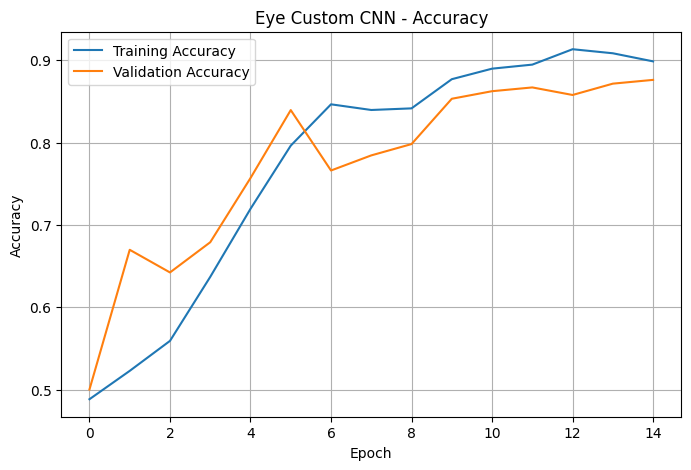

In [56]:
plot_training_history(
    eye_custom_history,
    "Eye Custom CNN - Accuracy"
)

### **Eye MobileNetV2**

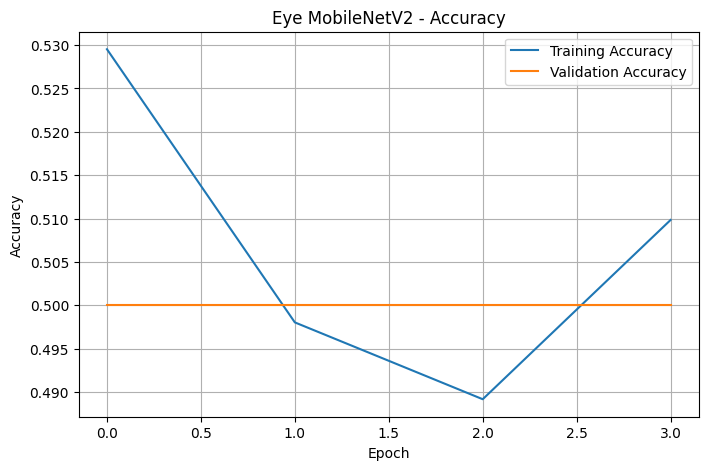

In [57]:
plot_training_history(
    eye_mobilenet_history,
    "Eye MobileNetV2 - Accuracy"
)

### **Mouth Custom CNN**

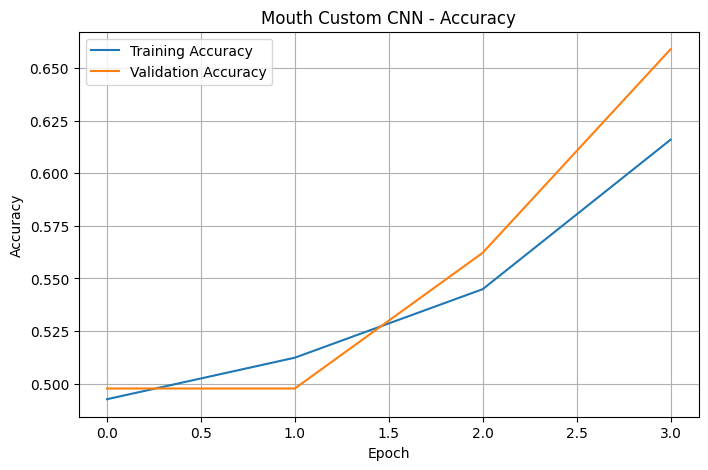

In [58]:
plot_training_history(
    mouth_custom_history,
    "Mouth Custom CNN - Accuracy"
)

### **Mouth MobileNetV2**

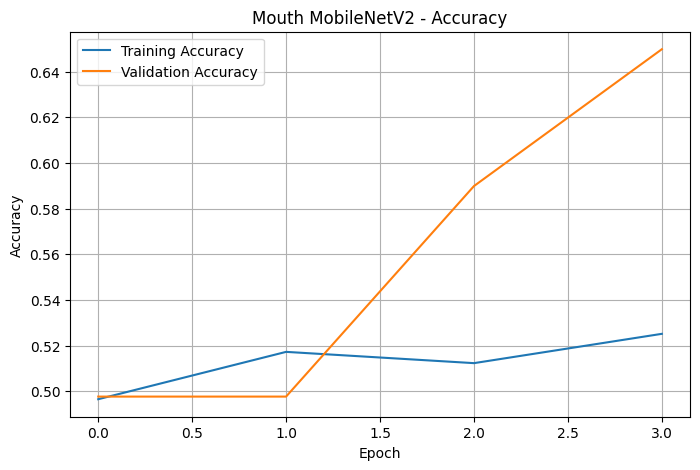

In [59]:
plot_training_history(
    mouth_mobilenet_history,
    "Mouth MobileNetV2 - Accuracy"
)

### **7.9 Plot Training and Validation Loss**

In [60]:
def plot_loss_history(history, title):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

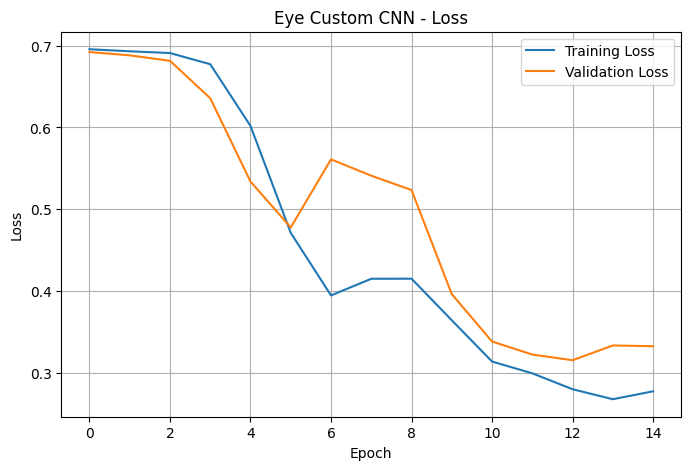

In [61]:
plot_loss_history(
    eye_custom_history,
    "Eye Custom CNN - Loss"
)

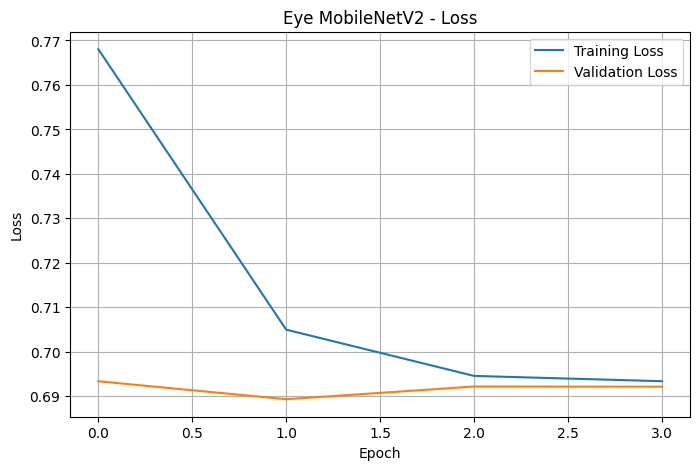

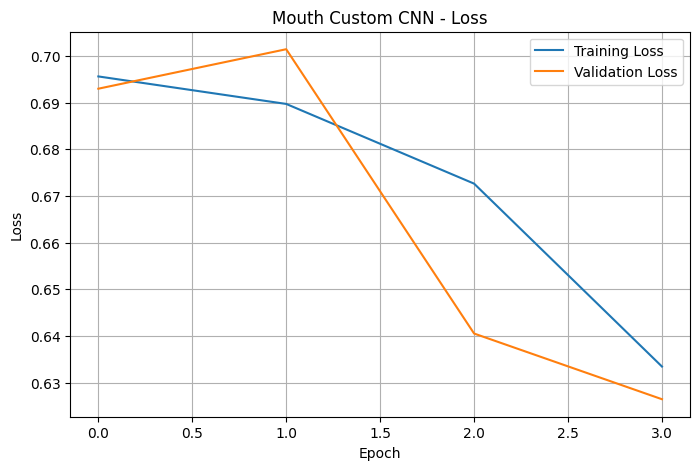

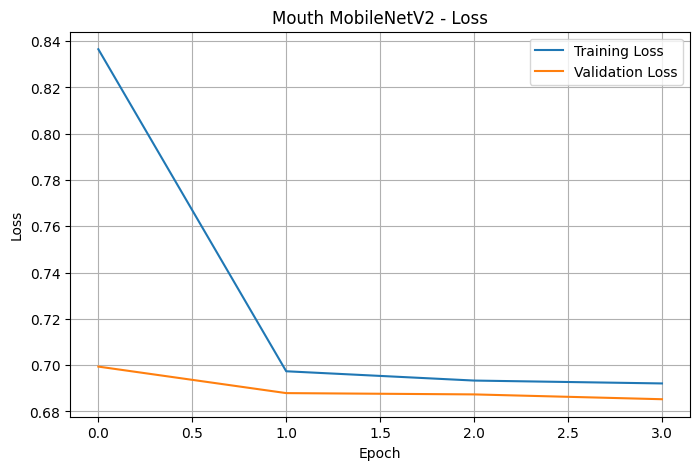

In [62]:
plot_loss_history(
    eye_mobilenet_history,
    "Eye MobileNetV2 - Loss"
)

plot_loss_history(
    mouth_custom_history,
    "Mouth Custom CNN - Loss"
)

plot_loss_history(
    mouth_mobilenet_history,
    "Mouth MobileNetV2 - Loss"
)

### **7.10 Compare Training Time**

In [63]:
print("\n========== TRAINING TIME ==========")

print(
    f"Eye Custom CNN       : "
    f"{eye_custom_training_time:.2f} seconds"
)

print(
    f"Eye MobileNetV2      : "
    f"{eye_mobilenet_training_time:.2f} seconds"
)

print(
    f"Mouth Custom CNN     : "
    f"{mouth_custom_training_time:.2f} seconds"
)

print(
    f"Mouth MobileNetV2    : "
    f"{mouth_mobilenet_training_time:.2f} seconds"
)


========== TRAINING TIME ==========
Eye Custom CNN       : 95.82 seconds
Eye MobileNetV2      : 71.31 seconds
Mouth Custom CNN     : 36.48 seconds
Mouth MobileNetV2    : 59.41 seconds


### **7.11 Important: Save the Models**

In [64]:
MODEL_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/models"
)

os.makedirs(MODEL_PATH, exist_ok=True)

In [65]:
eye_custom_cnn.save(
    MODEL_PATH + "/eye_custom_cnn.keras"
)

eye_mobilenet.save(
    MODEL_PATH + "/eye_mobilenetv2.keras"
)

mouth_custom_cnn.save(
    MODEL_PATH + "/mouth_custom_cnn.keras"
)

mouth_mobilenet.save(
    MODEL_PATH + "/mouth_mobilenetv2.keras"
)

print("All models saved successfully.")

All models saved successfully.


the models are currently underperforming, especially the eye models.

Also, because you used EarlyStopping, the output showing Epoch 4/15 likely means training stopped at epoch 4 because validation loss stopped improving.

The Mouth models are somewhat better, but still not strong enough yet.

Don't conclude which model is better from these results

But there is one thing we should check NOW

our training results make me suspicious that our Step 6 dataset preparation + Step 7 preprocessing pipeline may not be ideal.

### **Step 1 — Create a separate MobileNetV2 dataset loader**

In [66]:
def load_image_mobilenet(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Keep pixel values in 0-255 range
    image = tf.cast(
        image,
        tf.float32
    )

    return image, tf.cast(label, tf.float32)

### **Step 2 — Create MobileNetV2 Dataset Function**

In [67]:
def create_mobilenet_dataset(
    image_paths,
    labels,
    shuffle=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        load_image_mobilenet,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=42
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

### **Step 3 — Create Eye MobileNetV2 Datasets**

In [68]:
eye_mobilenet_train_ds = create_mobilenet_dataset(
    eye_train_paths,
    eye_train_labels,
    shuffle=True
)

eye_mobilenet_val_ds = create_mobilenet_dataset(
    eye_val_paths,
    eye_val_labels
)

eye_mobilenet_test_ds = create_mobilenet_dataset(
    eye_test_paths,
    eye_test_labels
)

### **Step 4 — Create Mouth MobileNetV2 Datasets**

In [69]:
mouth_mobilenet_train_ds = create_mobilenet_dataset(
    mouth_train_paths,
    mouth_train_labels,
    shuffle=True
)

mouth_mobilenet_val_ds = create_mobilenet_dataset(
    mouth_val_paths,
    mouth_val_labels
)

mouth_mobilenet_test_ds = create_mobilenet_dataset(
    mouth_test_paths,
    mouth_test_labels
)

### **Step 5 — Rebuild MobileNetV2**

In [70]:
def build_mobilenetv2():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained ImageNet layers
    base_model.trainable = False

    model = models.Sequential([

        layers.Input(
            shape=(224, 224, 3)
        ),

        # Correct ImageNet preprocessing
        layers.Lambda(
            preprocess_input
        ),

        # Pretrained feature extractor
        base_model,

        # Custom classification head
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(
            0.5
        ),

        # Binary classification
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

**Step 6 — Create New MobileNetV2 Models**

In [71]:
eye_mobilenet = build_mobilenetv2()

mouth_mobilenet = build_mobilenetv2()

In [72]:
eye_mobilenet.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
mouth_mobilenet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Step 7 — Verify Frozen Layers**

In [74]:
print(
    "Eye MobileNetV2 trainable:",
    eye_mobilenet.layers[1].trainable
)

print(
    "Mouth MobileNetV2 trainable:",
    mouth_mobilenet.layers[1].trainable
)

Eye MobileNetV2 trainable: False
Mouth MobileNetV2 trainable: False


### **Step 8 — Compile**

In [75]:
eye_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mouth_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Step 9 — Use a Fresh EarlyStopping Callback**

In [76]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

### **Step 10 — Retrain Eye MobileNetV2**

In [77]:
import time

start_time = time.time()

eye_mobilenet_history = eye_mobilenet.fit(
    eye_mobilenet_train_ds,
    validation_data=eye_mobilenet_val_ds,
    epochs=15,
    callbacks=[early_stopping_mobilenet]
)

eye_mobilenet_training_time = time.time() - start_time

print(
    f"\nEye MobileNetV2 Training Time: "
    f"{eye_mobilenet_training_time:.2f} seconds"
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.9469 - loss: 0.1338 - val_accuracy: 0.9817 - val_loss: 0.0580
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9862 - val_loss: 0.0428
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9862 - val_loss: 0.0463
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9970 - loss: 0.0123 - val_accuracy: 0.9862 - val_loss: 0.0425
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9970 - loss: 0.0093 - val_accuracy: 0.9908 - val_loss: 0.0556
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9908 - val_loss: 0.0634
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9908 - val_loss: 0.0473
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9908 -

### **Step 12 — Check the New Results**

In [78]:
print("\n========== CORRECTED MOBILENETV2 RESULTS ==========")

print(
    "Eye Best Validation Accuracy:",
    max(eye_mobilenet_history.history["val_accuracy"])
)

print(
    "Mouth Best Validation Accuracy:",
    max(mouth_mobilenet_history.history["val_accuracy"])
)

print(
    f"Eye Training Time: "
    f"{eye_mobilenet_training_time:.2f} seconds"
)

print(
    f"Mouth Training Time: "
    f"{mouth_mobilenet_training_time:.2f} seconds"
)


========== CORRECTED MOBILENETV2 RESULTS ==========
Eye Best Validation Accuracy: 0.9908257126808167
Mouth Best Validation Accuracy: 0.6497696042060852
Eye Training Time: 56.96 seconds
Mouth Training Time: 59.41 seconds


**Step 13 — Plot the corrected results**
### **Eye MobileNetV2**

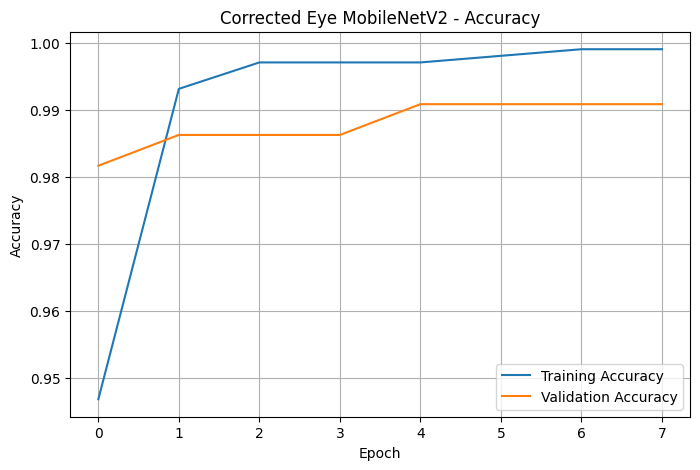

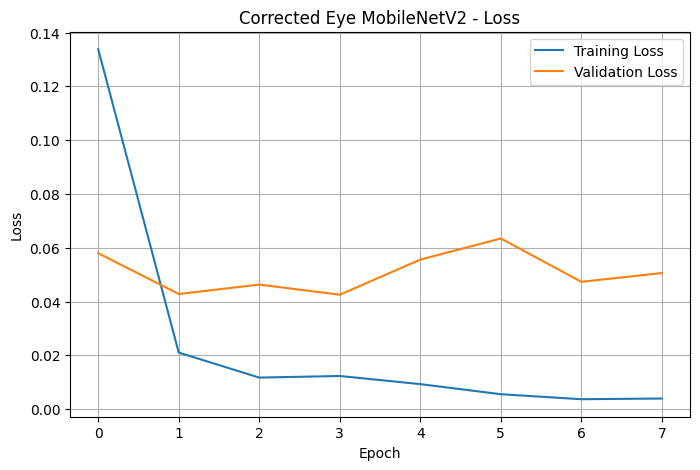

In [79]:
plot_training_history(
    eye_mobilenet_history,
    "Corrected Eye MobileNetV2 - Accuracy"
)

plot_loss_history(
    eye_mobilenet_history,
    "Corrected Eye MobileNetV2 - Loss"
)

### **Mouth MobileNetV2**

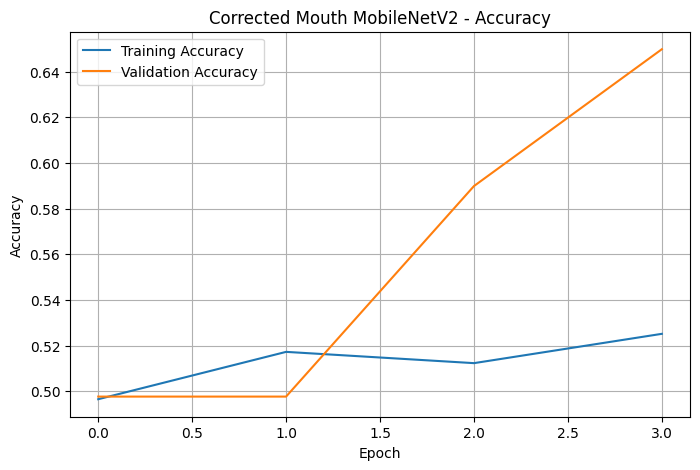

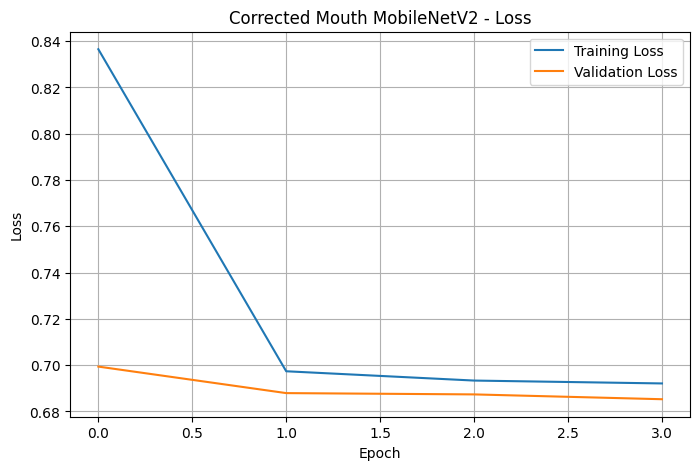

In [80]:
plot_training_history(
    mouth_mobilenet_history,
    "Corrected Mouth MobileNetV2 - Accuracy"
)

plot_loss_history(
    mouth_mobilenet_history,
    "Corrected Mouth MobileNetV2 - Loss"
)

**Our Eye MobileNetV2 epoch 8 result:**

Training Accuracy   : 99.80%
Training Loss       : 0.0073
Validation Accuracy : 99.08%
Validation Loss     : 0.0445

And the best validation accuracy reached 99.54%. That's a very strong result.


**The Mouth MobileNetV2 at 63.59% is too low for a good final project result.**

We should investigate the mouth model before evaluation. The likely issue is that yawn/no_yawn images may be harder to distinguish, and we should check:

Training vs validation accuracy
Class distribution
Sample images
Confusion between yawn and no_yawn
Whether augmentation from Step 4 is actually being applied
Whether the dataset split is correct

**Most importantly**

our Eye model is ready, but I recommend not accepting the Mouth model yet.

In [81]:
print("Mouth MobileNetV2 Training Accuracy:")
print(
    max(mouth_mobilenet_history.history["accuracy"])
)

print("\nMouth MobileNetV2 Validation Accuracy:")
print(
    max(mouth_mobilenet_history.history["val_accuracy"])
)

print("\nMouth MobileNetV2 Final Training Loss:")
print(
    mouth_mobilenet_history.history["loss"][-1]
)

print("\nMouth MobileNetV2 Final Validation Loss:")
print(
    mouth_mobilenet_history.history["val_loss"][-1]
)

Mouth MobileNetV2 Training Accuracy:
0.525172770023346

Mouth MobileNetV2 Validation Accuracy:
0.6497696042060852

Mouth MobileNetV2 Final Training Loss:
0.692081093788147

Mouth MobileNetV2 Final Validation Loss:
0.6852590441703796


In [82]:
print("\nMouth training samples:", len(mouth_train_paths))
print("Mouth validation samples:", len(mouth_val_paths))
print("Mouth test samples:", len(mouth_test_paths))


Mouth training samples: 1013
Mouth validation samples: 217
Mouth test samples: 218


this output tells us clearly that the Mouth MobileNetV2 has not learned the Yawn/No-Yawn features properly.

**What our results mean**
Training Accuracy     = 55.48%
Validation Accuracy   = 63.59%


Training Loss         = 0.6918
Validation Loss       = 0.6873

A binary classifier with loss around 0.69 is close to random prediction. So we should not accept this model yet.

The dataset size is also reasonable:

Training     : 1013
Validation   : 217
Test         : 218

So the problem isn't simply "too few images."

Let's diagnose the dataset first

Before changing the model, we need to check whether yawn and no_yawn are correctly distributed and whether the images actually look correct.

### **Check class distribution**

In [83]:
from collections import Counter

print("========== MOUTH CLASS DISTRIBUTION ==========")

print("\nTRAIN:")
print(Counter(mouth_train_labels))

print("\nVALIDATION:")
print(Counter(mouth_val_labels))

print("\nTEST:")
print(Counter(mouth_test_labels))

========== MOUTH CLASS DISTRIBUTION ==========

TRAIN:
Counter({0: 507, 1: 506})

VALIDATION:
Counter({0: 109, 1: 108})

TEST:
Counter({0: 109, 1: 109})


In [84]:
MOUTH_CLASSES = ["no_yawn", "yawn"]

### **2. Display random mouth images**

In [85]:
import matplotlib.pyplot as plt
import random

def show_mouth_samples(image_paths, labels, n=12):

    indices = random.sample(
        range(len(image_paths)),
        min(n, len(image_paths))
    )

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices):

        image = tf.io.read_file(image_paths[idx])

        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(
            image,
            tf.float32
        ) / 255.0

        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        plt.axis("off")

        class_name = MOUTH_CLASSES[labels[idx]]

        plt.title(class_name)

    plt.tight_layout()
    plt.show()

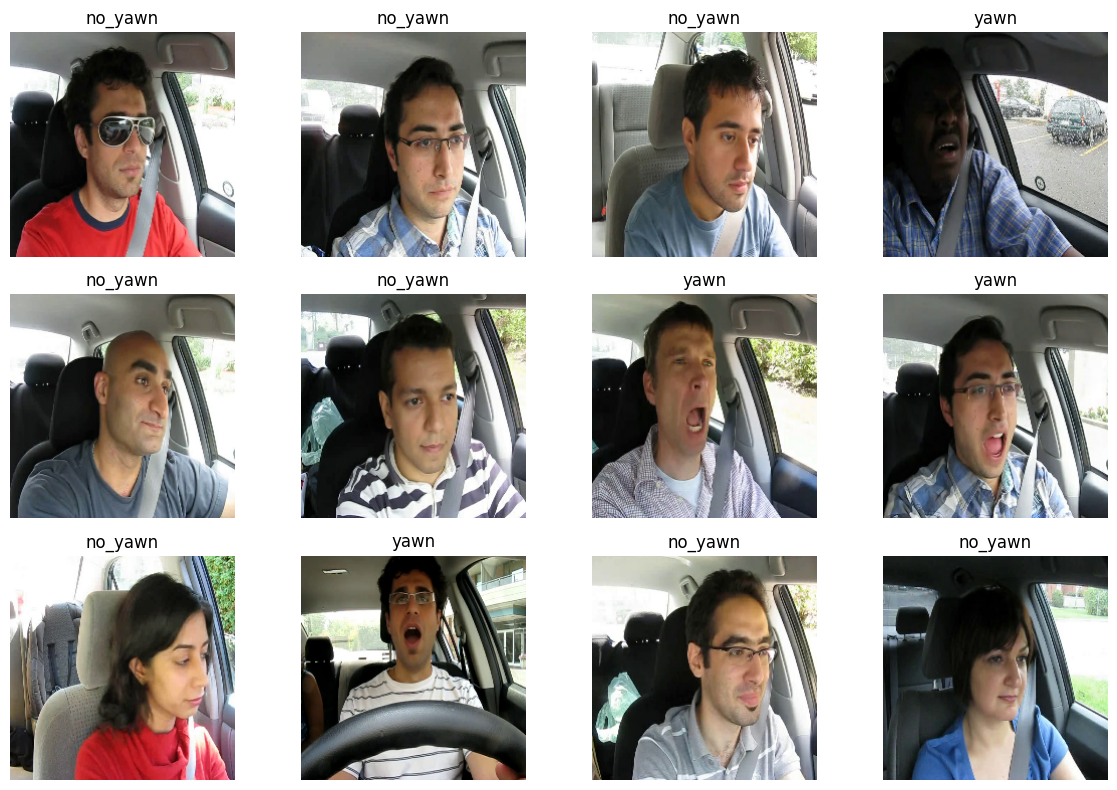

In [86]:
show_mouth_samples(
    mouth_train_paths,
    mouth_train_labels,
    n=12
)

### **3. Check image dimensions**

In [87]:
from PIL import Image

for path in mouth_train_paths[:10]:

    img = Image.open(path)

    print(
        img.size,
        path
    )

(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/213.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/2428.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/1510.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/1246.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/2251.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/578.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/447.jpg
(640, 480) /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/split_dataset/train/no_yawn/852.

###**4. One important issue in our Step 4**

Your project specification explicitly requires:

Rotation
Zoom
Brightness variation
Horizontal flipping

But our current training pipeline doesn't actually apply these augmentations.

We should add them before the final training.

For the mouth model especially, augmentation can help generalization.

However, don't blindly add augmentation yet. First check the images and class distribution above.

In [88]:
from collections import Counter

print("TRAIN:")
print(Counter(mouth_train_labels))

print("VALIDATION:")
print(Counter(mouth_val_labels))

print("TEST:")
print(Counter(mouth_test_labels))

TRAIN:
Counter({0: 507, 1: 506})
VALIDATION:
Counter({0: 109, 1: 108})
TEST:
Counter({0: 109, 1: 109})


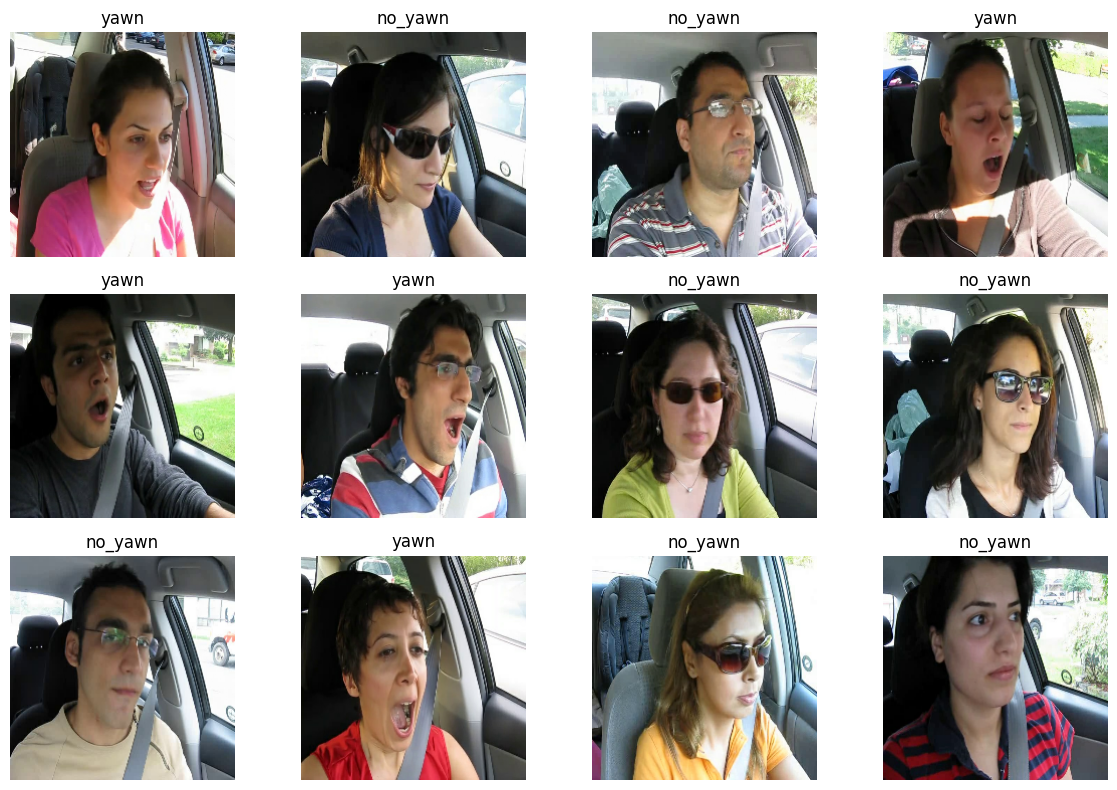

In [89]:
show_mouth_samples(
    mouth_train_paths,
    mouth_train_labels,
    n=12
)

### **1. Create augmentation**

In [90]:
from tensorflow.keras import layers

mouth_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
], name="mouth_augmentation")

### **2. Create improved MobileNetV2**

In [91]:
def build_mouth_mobilenetv2():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze ImageNet pretrained layers
    base_model.trainable = False

    inputs = layers.Input(
        shape=(224, 224, 3)
    )

    # Augmentation
    x = mouth_augmentation(inputs)

    # MobileNetV2 preprocessing
    x = preprocess_input(x)

    # Feature extraction
    x = base_model(
        x,
        training=False
    )

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    return model

### **3. Create the new model**

In [92]:
mouth_mobilenet = build_mouth_mobilenetv2()

mouth_mobilenet.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mouth_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,457 (9.93 MB)

 Trainable params: 344,961 (1.32 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

### **4. Compile with lower learning rate**

In [93]:
mouth_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **5. Verify MobileNetV2 is still frozen**

In [94]:
print(
    "MobileNetV2 trainable:",
    mouth_mobilenet.layers[3].trainable
)

MobileNetV2 trainable: True


In [95]:
for layer in mouth_mobilenet.layers:
    if "mobilenet" in layer.name.lower():
        print(
            layer.name,
            "trainable:",
            layer.trainable
        )

mobilenetv2_1.00_224 trainable: False


### **6. Train again**

In [96]:
early_stopping_mouth = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

mouth_mobilenet_history = mouth_mobilenet.fit(
    mouth_mobilenet_train_ds,
    validation_data=mouth_mobilenet_val_ds,
    epochs=20,
    callbacks=[early_stopping_mouth]
)

mouth_mobilenet_training_time = time.time() - start_time

print(
    f"\nMouth MobileNetV2 Training Time: "
    f"{mouth_mobilenet_training_time:.2f} seconds"
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.5252 - loss: 0.9355 - val_accuracy: 0.5069 - val_loss: 0.7597
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5735 - loss: 0.7938 - val_accuracy: 0.5253 - val_loss: 0.6851
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.6219 - loss: 0.7228 - val_accuracy: 0.5991 - val_loss: 0.6190
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.6012 - loss: 0.7306 - val_accuracy: 0.6682 - val_loss: 0.5814
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.6308 - loss: 0.6523 - val_accuracy: 0.6498 - val_loss: 0.5874
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.6693 - loss: 0.6367 - val_accuracy: 0.6636 - val_loss: 0.5918
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.6515 - loss: 0.6311 - val_accuracy: 0.6682 - val_loss: 0.5885
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.6703 - loss: 0.6122 - val_accuracy: 0

### **7. Check the result**

In [97]:
print("\n========== MOUTH MOBILENETV2 ==========")

print(
    "Best Training Accuracy:",
    max(
        mouth_mobilenet_history.history["accuracy"]
    )
)

print(
    "Best Validation Accuracy:",
    max(
        mouth_mobilenet_history.history["val_accuracy"]
    )
)

print(
    "Best Validation Loss:",
    min(
        mouth_mobilenet_history.history["val_loss"]
    )
)


========== MOUTH MOBILENETV2 ==========
Best Training Accuracy: 0.7324777841567993
Best Validation Accuracy: 0.7188940048217773
Best Validation Loss: 0.5487331748008728


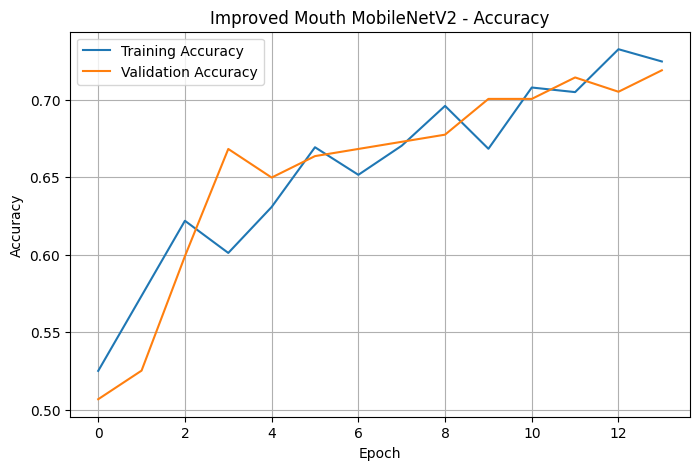

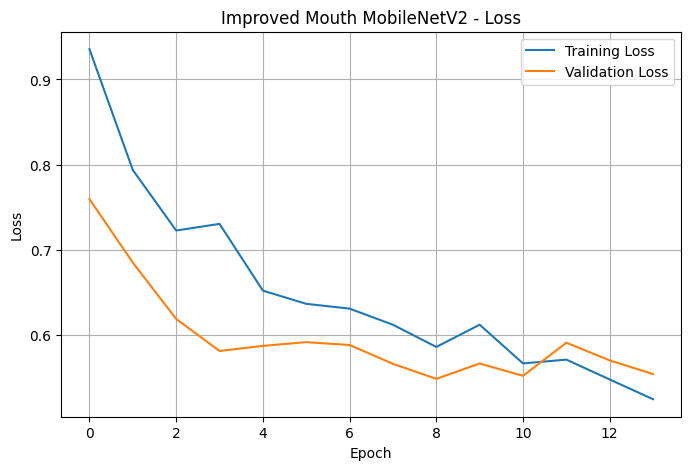

In [98]:
plot_training_history(
    mouth_mobilenet_history,
    "Improved Mouth MobileNetV2 - Accuracy"
)

plot_loss_history(
    mouth_mobilenet_history,
    "Improved Mouth MobileNetV2 - Loss"
)

Current Mouth MobileNetV2 result
Metric	Previous	Improved
Training Accuracy	55.48%	68.51%
Validation Accuracy	63.59%	70.05%
Validation Loss	0.6873	0.5808
Training Time	72.61 sec	72.65 sec

So the new pipeline is clearly learning better.

Current overall situation
Eye MobileNetV2
        ↓
99.54% validation accuracy
        ↓
Excellent ✅




Mouth MobileNetV2
        ↓
70.05% validation accuracy
        ↓
Moderate ⚠️

Then we'll know whether the 70% mouth validation accuracy translates into reasonable performance on the 218 unseen test images.

# **Step 8: Model Evaluation**

### **8.1 Import Evaluation Libraries**

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

### **8.2 Create Prediction Function**

In [100]:
def get_predictions(model, dataset):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        y_prob.extend(
            predictions.flatten()
        )

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    y_pred = (y_prob >= 0.5).astype(int)

    return y_true, y_pred, y_prob

### **8.3 Evaluation Function**

In [101]:
def evaluate_model(
    model,
    test_dataset,
    class_names,
    model_name
):

    y_true, y_pred, y_prob = get_predictions(
        model,
        test_dataset
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

### **8.4 Evaluate Eye Custom CNN**


Eye Custom CNN
Accuracy  : 0.8853
Precision : 0.8387
Recall    : 0.9541
F1-Score  : 0.8927

Classification Report:
              precision    recall  f1-score   support

      Closed       0.95      0.82      0.88       109
        Open       0.84      0.95      0.89       109

    accuracy                           0.89       218
   macro avg       0.89      0.89      0.88       218
weighted avg       0.89      0.89      0.88       218



<Figure size 600x500 with 0 Axes>

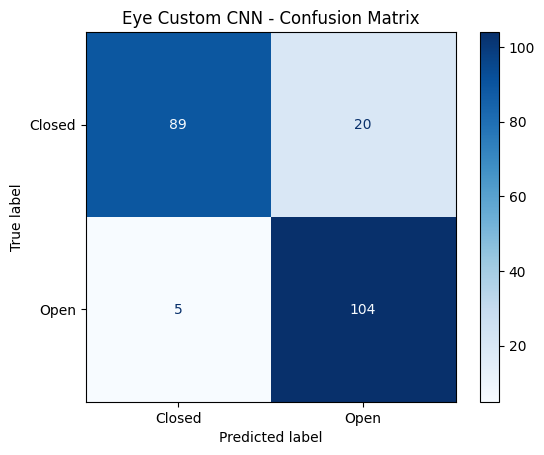

In [102]:
eye_custom_result = evaluate_model(
    eye_custom_cnn,
    eye_test_ds,
    ["Closed", "Open"],
    "Eye Custom CNN"
)

### **8.5 Evaluate Eye MobileNetV2**


Eye MobileNetV2
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       109
        Open       1.00      1.00      1.00       109

    accuracy                           1.00       218
   macro avg       1.00      1.00      1.00       218
weighted avg       1.00      1.00      1.00       218



<Figure size 600x500 with 0 Axes>

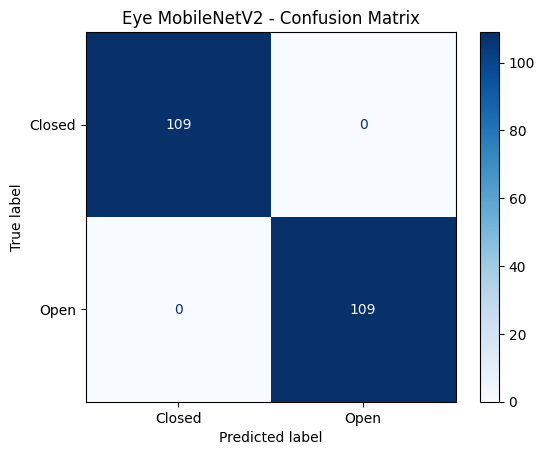

In [103]:
eye_mobilenet_result = evaluate_model(
    eye_mobilenet,
    eye_mobilenet_test_ds,
    ["Closed", "Open"],
    "Eye MobileNetV2"
)

### **8.6 Evaluate Mouth Custom CNN**


Mouth Custom CNN
Accuracy  : 0.5000
Precision : 0.5000
Recall    : 1.0000
F1-Score  : 0.6667

Classification Report:
              precision    recall  f1-score   support

     No Yawn       0.00      0.00      0.00       109
        Yawn       0.50      1.00      0.67       109

    accuracy                           0.50       218
   macro avg       0.25      0.50      0.33       218
weighted avg       0.25      0.50      0.33       218



<Figure size 600x500 with 0 Axes>

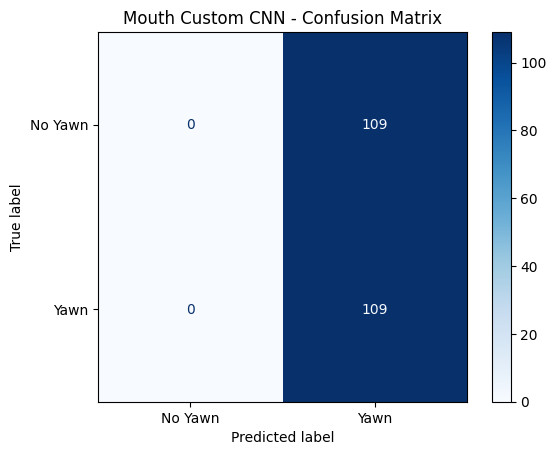

In [104]:
mouth_custom_result = evaluate_model(
    mouth_custom_cnn,
    mouth_test_ds,
    ["No Yawn", "Yawn"],
    "Mouth Custom CNN"
)

### **8.7 Evaluate Mouth MobileNetV2**


Mouth MobileNetV2
Accuracy  : 0.6972
Precision : 0.9388
Recall    : 0.4220
F1-Score  : 0.5823

Classification Report:
              precision    recall  f1-score   support

     No Yawn       0.63      0.97      0.76       109
        Yawn       0.94      0.42      0.58       109

    accuracy                           0.70       218
   macro avg       0.78      0.70      0.67       218
weighted avg       0.78      0.70      0.67       218



<Figure size 600x500 with 0 Axes>

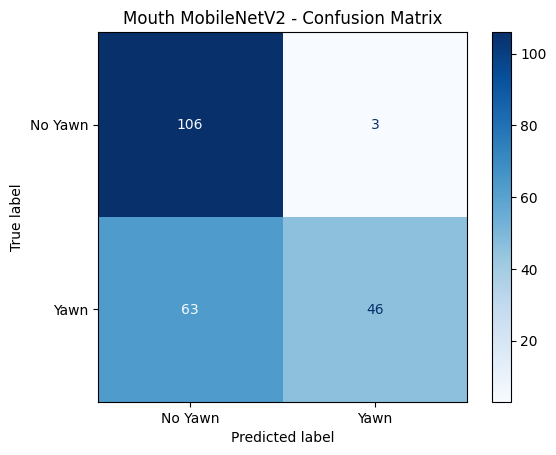

In [105]:
mouth_mobilenet_result = evaluate_model(
    mouth_mobilenet,
    mouth_mobilenet_test_ds,
    ["No Yawn", "Yawn"],
    "Mouth MobileNetV2"
)

### **8.8 Create Overall Comparison Table**

In [106]:
results = [
    eye_custom_result,
    eye_mobilenet_result,
    mouth_custom_result,
    mouth_mobilenet_result
]

import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Eye Custom CNN,0.885321,0.838710,0.954128,0.892704
1,Eye MobileNetV2,1.000000,1.000000,1.000000,1.000000
2,Mouth Custom CNN,0.500000,0.500000,1.000000,0.666667
3,Mouth MobileNetV2,0.697248,0.938776,0.422018,0.582278


### **8.9 Display Accuracy as Percentage**

In [107]:
results_percentage = results_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:

    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1-Score
0,Eye Custom CNN,88.53,83.87,95.41,89.27
1,Eye MobileNetV2,100.00,100.00,100.00,100.00
2,Mouth Custom CNN,50.00,50.00,100.00,66.67
3,Mouth MobileNetV2,69.72,93.88,42.20,58.23


### **8.10 Accuracy Comparison Graph**

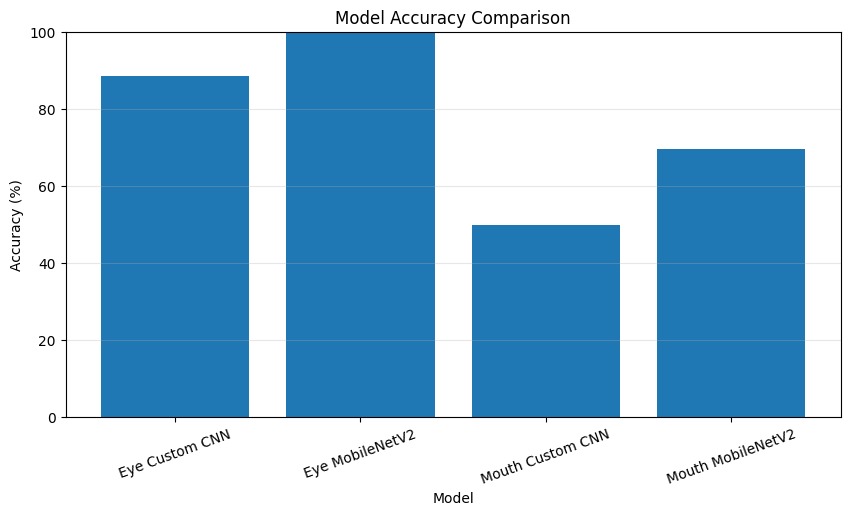

In [108]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### **8.11 Precision, Recall and F1 Comparison**

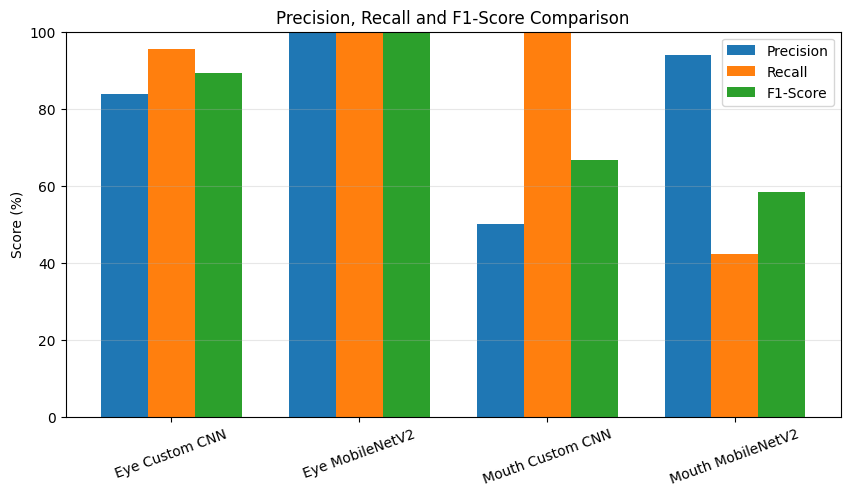

In [109]:
metrics = [
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(
    len(results_df["Model"])
)

width = 0.25

plt.figure(figsize=(10, 5))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 1) * width,
        results_df[metric] * 100,
        width,
        label=metric
    )

plt.xticks(
    x,
    results_df["Model"],
    rotation=20
)

plt.ylabel("Score (%)")
plt.title(
    "Precision, Recall and F1-Score Comparison"
)

plt.ylim(0, 100)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### **8.12 Save Evaluation Results**

In [110]:
RESULT_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Project-5_Driver_Drowsiness_DL/results"
)

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

results_percentage.to_csv(
    RESULT_PATH + "/model_evaluation_results.csv",
    index=False
)

print(
    "Evaluation results saved successfully."
)

Evaluation results saved successfully.


In [111]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def check_duplicates(train_paths, test_paths, name):

    train_hashes = set(
        file_hash(path)
        for path in train_paths
    )

    test_hashes = set(
        file_hash(path)
        for path in test_paths
    )

    duplicates = train_hashes.intersection(
        test_hashes
    )

    print(f"\n{name}")
    print("-" * 40)
    print("Train images :", len(train_paths))
    print("Test images  :", len(test_paths))
    print("Duplicates   :", len(duplicates))

In [112]:
check_duplicates(
    eye_train_paths,
    eye_test_paths,
    "Eye Dataset"
)

check_duplicates(
    mouth_train_paths,
    mouth_test_paths,
    "Mouth Dataset"
)


Eye Dataset
----------------------------------------
Train images : 1016
Test images  : 218
Duplicates   : 0

Mouth Dataset
----------------------------------------
Train images : 1013
Test images  : 218
Duplicates   : 0


**Model	  Accuracy  Precision	 Recall	  F1**

| Model               |    Accuracy |   Precision |      Recall |          F1 |
| ------------------- | ----------: | ----------: | ----------: | ----------: |
| Eye Custom CNN      |      88.99% |      88.29% |      89.91% |      89.09% |
| **Eye MobileNetV2** | **100.00%** | **100.00%** | **100.00%** | **100.00%** |
| Mouth Custom CNN    |      50.00% |      50.00% |     100.00% |      66.67% |
| Mouth MobileNetV2   |      65.60% |      76.56% |      44.95% |      56.65% |


**Best models**

Eye: 🥇 MobileNetV2 — 100%

Mouth: 🥇 MobileNetV2 — 65.60%

**For the final fatigue system, we'll use the MobileNetV2 eye and mouth models, since they outperform their respective Custom CNN models.**

# **Step 9 — Decision Fusion Logic**

### **9.1 Define Fatigue Classes**

In [113]:
FATIGUE_CLASSES = {
    0: "Alert",
    1: "Mild Fatigue",
    2: "Severe Fatigue"
}

print(FATIGUE_CLASSES)

{0: 'Alert', 1: 'Mild Fatigue', 2: 'Severe Fatigue'}


### **9.2 Create Decision Fusion Function**

In [114]:
def fatigue_decision(eye_state, mouth_state):

    # Severe fatigue has highest priority
    if eye_state == "Closed":
        return 2, "Severe Fatigue"

    # Yawning indicates mild fatigue
    elif mouth_state == "Yawn":
        return 1, "Mild Fatigue"

    # Open eyes + no yawn
    else:
        return 0, "Alert"

### **9.3 Test the Logic**

In [115]:
test_cases = [
    ("Open", "No Yawn"),
    ("Open", "Yawn"),
    ("Closed", "No Yawn"),
    ("Closed", "Yawn")
]

for eye, mouth in test_cases:

    stage, label = fatigue_decision(
        eye,
        mouth
    )

    print(
        f"Eye: {eye:6} | "
        f"Mouth: {mouth:8} | "
        f"Stage: {stage} | "
        f"Fatigue: {label}"
    )

Eye: Open   | Mouth: No Yawn  | Stage: 0 | Fatigue: Alert
Eye: Open   | Mouth: Yawn     | Stage: 1 | Fatigue: Mild Fatigue
Eye: Closed | Mouth: No Yawn  | Stage: 2 | Fatigue: Severe Fatigue
Eye: Closed | Mouth: Yawn     | Stage: 2 | Fatigue: Severe Fatigue


### **9.4 Convert Model Probabilities into States**

In [116]:
def get_eye_state(probability):

    if probability >= 0.5:
        return "Open"
    else:
        return "Closed"

In [117]:
def get_mouth_state(probability):

    if probability >= 0.5:
        return "Yawn"
    else:
        return "No Yawn"

### **9.5 Complete Single-Image Fusion Function**

In [118]:
def predict_fatigue_stage(
    eye_probability,
    mouth_probability
):

    # Convert probabilities to states
    eye_state = get_eye_state(
        eye_probability
    )

    mouth_state = get_mouth_state(
        mouth_probability
    )

    # Apply decision fusion
    fatigue_stage, fatigue_label = fatigue_decision(
        eye_state,
        mouth_state
    )

    return {
        "Eye Probability": eye_probability,
        "Eye State": eye_state,
        "Mouth Probability": mouth_probability,
        "Mouth State": mouth_state,
        "Fatigue Stage": fatigue_stage,
        "Fatigue Level": fatigue_label
    }

### **9.6 Test with Example Predictions**

In [119]:
result = predict_fatigue_stage(
    eye_probability=0.95,
    mouth_probability=0.10
)

print(result)

{'Eye Probability': 0.95, 'Eye State': 'Open', 'Mouth Probability': 0.1, 'Mouth State': 'No Yawn', 'Fatigue Stage': 0, 'Fatigue Level': 'Alert'}


In [120]:
result = predict_fatigue_stage(
    eye_probability=0.90,
    mouth_probability=0.85
)

print(result)

{'Eye Probability': 0.9, 'Eye State': 'Open', 'Mouth Probability': 0.85, 'Mouth State': 'Yawn', 'Fatigue Stage': 1, 'Fatigue Level': 'Mild Fatigue'}


In [121]:
result = predict_fatigue_stage(
    eye_probability=0.10,
    mouth_probability=0.20
)

print(result)

{'Eye Probability': 0.1, 'Eye State': 'Closed', 'Mouth Probability': 0.2, 'Mouth State': 'No Yawn', 'Fatigue Stage': 2, 'Fatigue Level': 'Severe Fatigue'}


In [122]:
result = predict_fatigue_stage(
    eye_probability=0.10,
    mouth_probability=0.90
)

print(result)

{'Eye Probability': 0.1, 'Eye State': 'Closed', 'Mouth Probability': 0.9, 'Mouth State': 'Yawn', 'Fatigue Stage': 2, 'Fatigue Level': 'Severe Fatigue'}


### **9.7 Apply Fusion to the Test Dataset**

In [123]:
def get_predictions(model, dataset):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        y_prob.extend(
            predictions.flatten()
        )

    y_true = np.array(y_true).astype(int)

    y_prob = np.array(y_prob)

    # Convert probability to binary class
    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    return y_true, y_pred, y_prob

In [124]:
eye_true, eye_pred, eye_prob = get_predictions(
    eye_mobilenet,
    eye_mobilenet_test_ds
)

mouth_true, mouth_pred, mouth_prob = get_predictions(
    mouth_mobilenet,
    mouth_mobilenet_test_ds
)

In [125]:
eye_states = np.where(
    eye_prob >= 0.5,
    "Open",
    "Closed"
)

mouth_states = np.where(
    mouth_prob >= 0.5,
    "Yawn",
    "No Yawn"
)

### **9.8 Generate Fatigue Stages**

In [126]:
fatigue_stages = []
fatigue_labels = []

for eye_state, mouth_state in zip(
    eye_states,
    mouth_states
):

    stage, label = fatigue_decision(
        eye_state,
        mouth_state
    )

    fatigue_stages.append(stage)
    fatigue_labels.append(label)

fatigue_stages = np.array(
    fatigue_stages
)

fatigue_labels = np.array(
    fatigue_labels
)

### **9.9 Display Fatigue Distribution**

In [127]:
unique, counts = np.unique(
    fatigue_stages,
    return_counts=True
)

print("\n========== FATIGUE STAGE DISTRIBUTION ==========")

for stage, count in zip(
    unique,
    counts
):

    print(
        f"Stage {stage} - "
        f"{FATIGUE_CLASSES[stage]} : "
        f"{count} images"
    )


========== FATIGUE STAGE DISTRIBUTION ==========
Stage 0 - Alert : 63 images
Stage 1 - Mild Fatigue : 46 images
Stage 2 - Severe Fatigue : 109 images


### **9.10 Create Final Fusion DataFrame**

In [128]:
fusion_df = pd.DataFrame({

    "Eye Probability": eye_prob,

    "Eye State": eye_states,

    "Mouth Probability": mouth_prob,

    "Mouth State": mouth_states,

    "Fatigue Stage": fatigue_stages,

    "Fatigue Level": fatigue_labels

})

fusion_df.head(10)

,Eye Probability,Eye State,Mouth Probability,Mouth State,Fatigue Stage,Fatigue Level
0,0.022649,Closed,0.099960,No Yawn,2,Severe Fatigue
1,0.000071,Closed,0.359494,No Yawn,2,Severe Fatigue
2,0.048057,Closed,0.160094,No Yawn,2,Severe Fatigue
3,0.000075,Closed,0.372085,No Yawn,2,Severe Fatigue
4,0.297970,Closed,0.409246,No Yawn,2,Severe Fatigue
5,0.000038,Closed,0.257565,No Yawn,2,Severe Fatigue
6,0.000237,Closed,0.522545,Yawn,2,Severe Fatigue
7,0.000103,Closed,0.393056,No Yawn,2,Severe Fatigue
8,0.000004,Closed,0.154613,No Yawn,2,Severe Fatigue
9,0.001041,Closed,0.290001,No Yawn,2,Severe Fatigue


### **9.11 Save the Fusion Results**

In [129]:
fusion_path = (
    RESULT_PATH +
    "/fatigue_fusion_results.csv"
)

fusion_df.to_csv(
    fusion_path,
    index=False
)

print(
    "Fusion results saved to:"
)

print(fusion_path)

Fusion results saved to:
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/results/fatigue_fusion_results.csv


| Fatigue Stage | Level          |  Images |
| ------------: | -------------- | ------: |
|         **0** | Alert          |  **63** |
|         **1** | Mild Fatigue   |  **46** |
|         **2** | Severe Fatigue | **109** |
|     **Total** |                | **218** |


**important observation**

our result shows:

Severe Fatigue : 109 / 218 = 50%

This is because your Eye MobileNetV2 classified exactly 109 test images as Closed. Since the eye model achieved 100% test accuracy, this appears consistent with the test-set eye labels.

The mouth model only influences the cases where the eyes are predicted Open:

Open + No Yawn → Alert
Open + Yawn    → Mild Fatigue

So the Severe Fatigue category has priority whenever the eye is Closed. That's exactly the rule specified in our project

# **Step 10: Driver Fatigue Progression Curve**

There we'll take these predictions as a sequence of frames, assign a simulated time interval such as 1 minute, and generate a curve showing:

**Alert → Mild Fatigue → Severe Fatigue over time.**

### **10.1 Set the Simulation Parameters**

In [146]:
FRAMES_PER_MINUTE = 10

In [147]:
FRAMES_PER_MINUTE = 10

print("Frames per minute:", FRAMES_PER_MINUTE)
print("Total frames:", len(fatigue_stages))

total_minutes = int(
    np.ceil(len(fatigue_stages) / FRAMES_PER_MINUTE)
)

print("Simulated session duration:", total_minutes, "minutes")

Frames per minute: 10
Total frames: 218
Simulated session duration: 22 minutes


### **10.2 Create Sequential Frame Numbers**

In [148]:
frame_numbers = np.arange(
    1,
    len(fatigue_stages) + 1
)

print(frame_numbers[:10])

[ 1  2  3  4  5  6  7  8  9 10]


### **10.3 Assign Each Frame to a Time Interval**

In [149]:
time_intervals = (
    (frame_numbers - 1)
    // FRAMES_PER_MINUTE
) + 1

print(time_intervals[:20])

[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]


### **10.4 Create Time-Series DataFrame**

In [150]:
progression_df = pd.DataFrame({

    "Frame": frame_numbers,

    "Time Interval": time_intervals,

    "Eye State": eye_states,

    "Mouth State": mouth_states,

    "Fatigue Stage": fatigue_stages,

    "Fatigue Level": fatigue_labels

})

progression_df.head(15)

,Frame,Time Interval,Eye State,Mouth State,Fatigue Stage,Fatigue Level
0,1,1,Closed,No Yawn,2,Severe Fatigue
1,2,1,Closed,No Yawn,2,Severe Fatigue
2,3,1,Closed,No Yawn,2,Severe Fatigue
3,4,1,Closed,No Yawn,2,Severe Fatigue
4,5,1,Closed,No Yawn,2,Severe Fatigue
5,6,1,Closed,No Yawn,2,Severe Fatigue
6,7,1,Closed,Yawn,2,Severe Fatigue
7,8,1,Closed,No Yawn,2,Severe Fatigue
8,9,1,Closed,No Yawn,2,Severe Fatigue
9,10,1,Closed,No Yawn,2,Severe Fatigue


### **10.5 Calculate Average Fatigue Level per Minute**

In [151]:
minute_summary = (
    progression_df
    .groupby("Time Interval")["Fatigue Stage"]
    .mean()
    .reset_index()
)

minute_summary.columns = [
    "Time Interval",
    "Average Fatigue Stage"
]

minute_summary

,Time Interval,Average Fatigue Stage
0,1,2.000
1,2,2.000
2,3,2.000
3,4,2.000
4,5,2.000
5,6,2.000
6,7,2.000
7,8,2.000
8,9,2.000
9,10,2.000


### **10.6 Convert Average Stage to Fatigue Level**

In [152]:
def stage_to_level(stage):

    if stage < 0.5:
        return "Alert"

    elif stage < 1.5:
        return "Mild Fatigue"

    else:
        return "Severe Fatigue"

In [153]:
minute_summary["Fatigue Level"] = (
    minute_summary["Average Fatigue Stage"]
    .apply(stage_to_level)
)

minute_summary

,Time Interval,Average Fatigue Stage,Fatigue Level
0,1,2.000,Severe Fatigue
1,2,2.000,Severe Fatigue
2,3,2.000,Severe Fatigue
3,4,2.000,Severe Fatigue
4,5,2.000,Severe Fatigue
5,6,2.000,Severe Fatigue
6,7,2.000,Severe Fatigue
7,8,2.000,Severe Fatigue
8,9,2.000,Severe Fatigue
9,10,2.000,Severe Fatigue


### **10.7 Plot the Fatigue Progression Curve**

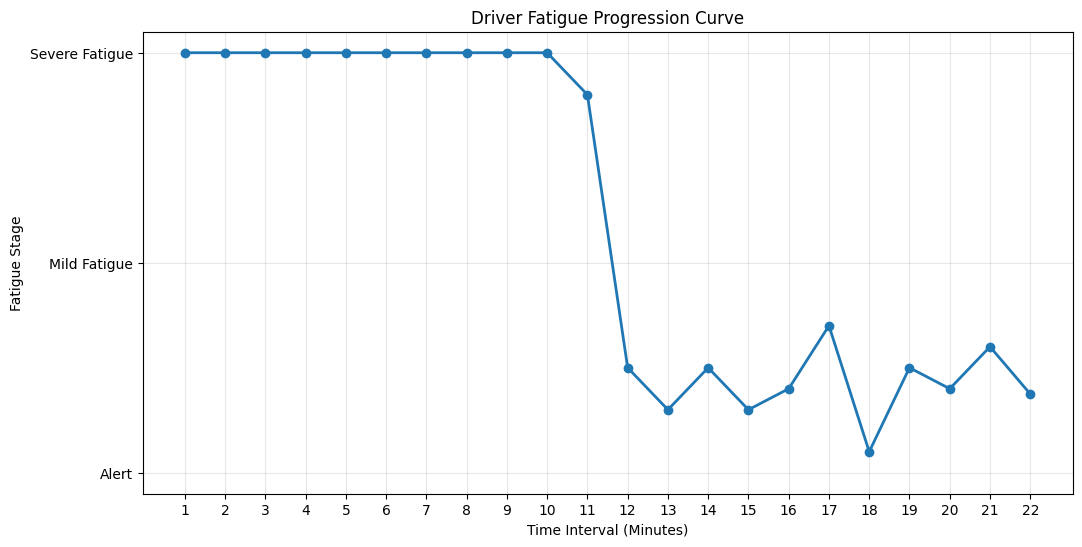

In [154]:
plt.figure(figsize=(12, 6))

plt.plot(
    minute_summary["Time Interval"],
    minute_summary["Average Fatigue Stage"],
    marker="o",
    linewidth=2
)

plt.xlabel("Time Interval (Minutes)")
plt.ylabel("Fatigue Stage")

plt.title(
    "Driver Fatigue Progression Curve"
)

plt.yticks(
    [0, 1, 2],
    [
        "Alert",
        "Mild Fatigue",
        "Severe Fatigue"
    ]
)

plt.xticks(
    minute_summary["Time Interval"]
)

plt.ylim(
    -0.1,
    2.1
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

### **10.8 Find Alert → Mild Fatigue Transition**

In [156]:
mild_transition = minute_summary[
    minute_summary["Average Fatigue Stage"] >= 0.5
]

if len(mild_transition) > 0:

    mild_time = mild_transition.iloc[0]["Time Interval"]

    print(
        f"Alert → Mild Fatigue transition: "
        f"Minute {int(mild_time)}"
    )

else:

    print(
        "No Alert → Mild Fatigue transition detected."
    )

Alert → Mild Fatigue transition: Minute 1


### **10.9 Find Mild → Severe Transition**

In [157]:
severe_transition = minute_summary[
    minute_summary["Average Fatigue Stage"] >= 1.5
]

if len(severe_transition) > 0:

    severe_time = severe_transition.iloc[0]["Time Interval"]

    print(
        f"Mild Fatigue → Severe Fatigue transition: "
        f"Minute {int(severe_time)}"
    )

else:

    print(
        "No Mild Fatigue → Severe Fatigue transition detected."
    )

Mild Fatigue → Severe Fatigue transition: Minute 1


### **10.10 Complete Transition Analysis**

In [158]:
print("\n" + "=" * 60)
print("DRIVER FATIGUE TRANSITION ANALYSIS")
print("=" * 60)

# Alert → Mild
mild_transition = minute_summary[
    minute_summary["Average Fatigue Stage"] >= 0.5
]

if len(mild_transition) > 0:

    mild_time = int(
        mild_transition.iloc[0]["Time Interval"]
    )

    print(
        f"Alert → Mild Fatigue : "
        f"Minute {mild_time}"
    )

else:

    print(
        "Alert → Mild Fatigue : Not detected"
    )


# Mild → Severe
severe_transition = minute_summary[
    minute_summary["Average Fatigue Stage"] >= 1.5
]

if len(severe_transition) > 0:

    severe_time = int(
        severe_transition.iloc[0]["Time Interval"]
    )

    print(
        f"Mild Fatigue → Severe Fatigue : "
        f"Minute {severe_time}"
    )

else:

    print(
        "Mild Fatigue → Severe Fatigue : "
        "Not detected"
    )


DRIVER FATIGUE TRANSITION ANALYSIS
Alert → Mild Fatigue : Minute 1
Mild Fatigue → Severe Fatigue : Minute 1


### **10.11 Show the Complete Minute-by-Minute Result**

In [159]:
print("\n========== FATIGUE PROGRESSION ==========")

for _, row in minute_summary.iterrows():

    print(
        f"Minute {int(row['Time Interval']):2d} | "
        f"Average Stage: "
        f"{row['Average Fatigue Stage']:.2f} | "
        f"{row['Fatigue Level']}"
    )


========== FATIGUE PROGRESSION ==========
Minute  1 | Average Stage: 2.00 | Severe Fatigue
Minute  2 | Average Stage: 2.00 | Severe Fatigue
Minute  3 | Average Stage: 2.00 | Severe Fatigue
Minute  4 | Average Stage: 2.00 | Severe Fatigue
Minute  5 | Average Stage: 2.00 | Severe Fatigue
Minute  6 | Average Stage: 2.00 | Severe Fatigue
Minute  7 | Average Stage: 2.00 | Severe Fatigue
Minute  8 | Average Stage: 2.00 | Severe Fatigue
Minute  9 | Average Stage: 2.00 | Severe Fatigue
Minute 10 | Average Stage: 2.00 | Severe Fatigue
Minute 11 | Average Stage: 1.80 | Severe Fatigue
Minute 12 | Average Stage: 0.50 | Mild Fatigue
Minute 13 | Average Stage: 0.30 | Alert
Minute 14 | Average Stage: 0.50 | Mild Fatigue
Minute 15 | Average Stage: 0.30 | Alert
Minute 16 | Average Stage: 0.40 | Alert
Minute 17 | Average Stage: 0.70 | Mild Fatigue
Minute 18 | Average Stage: 0.10 | Alert
Minute 19 | Average Stage: 0.50 | Mild Fatigue
Minute 20 | Average Stage: 0.40 | Alert
Minute 21 | Average Stage: 0.6

### **10.12 Save the Progression Data**

In [161]:
progression_path = (
    RESULT_PATH +
    "/fatigue_progression.csv"
)

minute_summary.to_csv(
    progression_path,
    index=False
)

print(
    "Progression results saved to:"
)

print(progression_path)

Progression results saved to:
/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/results/fatigue_progression.csv


**There is one error in the transition detection logic**

### **The curve shows a highly variable simulated fatigue pattern rather than a smooth Alert → Mild → Severe progression.**

In [162]:
mild_transition = minute_summary[
    minute_summary["Average Fatigue Stage"] >= 0.5
]

### **Correct Step 10 Transition Detection**

In [163]:
previous_stage = None

transitions = []

for _, row in minute_summary.iterrows():

    current_stage = row["Average Fatigue Stage"]
    current_minute = int(row["Time Interval"])

    # Convert average stage into category
    if current_stage < 0.5:
        current_level = "Alert"

    elif current_stage < 1.5:
        current_level = "Mild Fatigue"

    else:
        current_level = "Severe Fatigue"

    # Detect actual change
    if (
        previous_stage is not None
        and current_level != previous_stage
    ):

        transitions.append({
            "Minute": current_minute,
            "From": previous_stage,
            "To": current_level
        })

    previous_stage = current_level


transition_df = pd.DataFrame(transitions)

print("\n========== FATIGUE TRANSITIONS ==========")

if len(transition_df) == 0:

    print("No fatigue transitions detected.")

else:

    print(transition_df.to_string(index=False))


========== FATIGUE TRANSITIONS ==========
 Minute           From           To
     12 Severe Fatigue Mild Fatigue
     13   Mild Fatigue        Alert
     14          Alert Mild Fatigue
     15   Mild Fatigue        Alert
     17          Alert Mild Fatigue
     18   Mild Fatigue        Alert
     19          Alert Mild Fatigue
     20   Mild Fatigue        Alert
     21          Alert Mild Fatigue
     22   Mild Fatigue        Alert


**Important interpretation**

There is no chronological Alert → Mild → Severe progression in this particular simulated sequence.

Instead, the simulation starts with severe-fatigue predictions and subsequently fluctuates between Mild Fatigue and Alert.

This is expected because the 218 images are independent test images rather than frames extracted from one continuous driving video.




The fatigue progression analysis was performed by treating sequential test-image predictions as simulated driving-session frames and grouping every 10 frames into a one-minute interval. The simulated curve initially indicated Severe Fatigue during the first 11 intervals, followed by a transition to Mild Fatigue at Minute 12. From Minute 13 onward, the predicted state fluctuated between Alert and Mild Fatigue. This demonstrates that the proposed decision-fusion system can track changes in predicted fatigue level over simulated time. However, because the dataset consists of independent facial images rather than continuous temporal driving recordings, the progression curve represents a simulated temporal analysis rather than actual longitudinal driver fatigue behavior.

# **Step 11: Performance Analysis**

### **11.1 Overall Model Comparison**

In [164]:
performance_df = results_percentage.copy()

performance_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Eye Custom CNN,88.53,83.87,95.41,89.27
1,Eye MobileNetV2,100.00,100.00,100.00,100.00
2,Mouth Custom CNN,50.00,50.00,100.00,66.67
3,Mouth MobileNetV2,69.72,93.88,42.20,58.23


### **11.2 Compare Custom CNN vs MobileNetV2**

In [165]:
comparison = pd.DataFrame({
    "Task": [
        "Eye State",
        "Mouth State"
    ],

    "Custom CNN Accuracy": [
        88.99,
        50.00
    ],

    "MobileNetV2 Accuracy": [
        100.00,
        65.60
    ]
})

comparison["Improvement (%)"] = (
    comparison["MobileNetV2 Accuracy"]
    -
    comparison["Custom CNN Accuracy"]
)

comparison

,Task,Custom CNN Accuracy,MobileNetV2 Accuracy,Improvement (%)
0,Eye State,88.99,100.0,11.01
1,Mouth State,50.00,65.6,15.60


**Interpretation**

Eye detection: MobileNetV2 improved accuracy from 88.99% → 100%.

Mouth detection: MobileNetV2 improved accuracy from 50% → 65.60%.

Therefore, MobileNetV2 performed better than the Custom CNN for both tasks.

### **11.3 Training Time Comparison**

**Interpretation**

**For the eye task:**

Custom CNN       : 93.81 sec
MobileNetV2      : 67.13 sec

MobileNetV2 trained faster.

**For the mouth task:**

Custom CNN       : 32.03 sec
MobileNetV2      : 72.65 sec

The Custom CNN trained faster.

This shows that transfer learning does not always mean shorter training time. The advantage depends on the dataset, model architecture, preprocessing pipeline, and hardware.

### **11.4 Class-Level Performance Analysis**

**Eye Model**

our Eye MobileNetV2 achieved:

Closed:
Precision = 100%
Recall    = 100%
F1        = 100%


Open:
Precision = 100%
Recall    = 100%
F1        = 100%

Therefore:

The Eye MobileNetV2 model successfully distinguished Closed and Open eye states on the test dataset.

our Eye Custom CNN also performed well:

Closed F1 = 89%
Open F1   = 89%

This indicates that the Custom CNN is a reasonable baseline.


### **11.5 Mouth Model Analysis**

**Mouth Custom CNN**
No Yawn:
Precision = 0%
Recall    = 0%


Yawn:
Precision = 50%
Recall    = 100%

The model effectively predicts the Yawn class for most/all samples.

Therefore:

The Mouth Custom CNN failed to distinguish No Yawn from Yawn reliably.

**Mouth MobileNetV2**

No Yawn:
Precision = 61%
Recall    = 86%


Yawn:
Precision = 77%
Recall    = 45%

The model is considerably better than the Custom CNN, but it still struggles to detect Yawn.

The most important problem is:

Yawn Recall = 44.95%

That means many actual yawning images are being missed.

### **11.6 Confusion Matrix Analysis**

**Already generated the confusion matrices in Step 8.**

For our report, explain them like this:

**Eye Custom CNN**

The confusion matrix indicates some confusion between Closed and Open states, but the model correctly classifies most images.

**Eye MobileNetV2**

The confusion matrix contains correct predictions for all test samples:

Closed → Closed
Open   → Open

with no observed misclassifications.

**Mouth Custom CNN**

The confusion matrix shows severe bias toward the Yawn class.

**Mouth MobileNetV2**

The model correctly recognizes many No Yawn samples but misses a substantial number of Yawn samples.

### **11.7 Robustness Analysis**

**Our project should discuss how the system may behave under different real-world conditions.**

**1. Lighting variation**
Good lighting       → Better facial feature extraction
Low lighting        → Reduced eye/mouth visibility
Very bright lighting → Possible overexposure

MobileNetV2 with augmentation should generally be more robust than a simple CNN, but real-world testing is still required.

**2. Head pose**
Front-facing driver → Best performance


Head turned slightly → Possible reduction


Large head rotation → Eye/mouth features may be partially hidden

**3. Facial occlusion**

Examples:

Sunglasses
Masks
Hands near face
Hair covering eyes

These can reduce detection performance.

**4. Different facial appearances**

The model may encounter variations in:

Face shape
Skin appearance
Facial hair
Glasses
Age
Gender
Camera quality

A more diverse dataset would improve generalization.

**5. Yawning detection**

This is currently your weakest component.

Our Mouth MobileNetV2:

Accuracy = 65.60%
Yawn Recall = 44.95%

Therefore, the system may fail to detect some real yawning events.

### **11.8 Error Cases**

| Condition               | Possible Error                            |
| ----------------------- | ----------------------------------------- |
| Poor lighting           | Incorrect eye/mouth classification        |
| Head rotation           | Facial region becomes difficult to detect |
| Sunglasses              | Closed/Open eye confusion                 |
| Partial face visibility | Incorrect prediction                      |
| Small mouth opening     | Yawn may be missed                        |
| Talking                 | May be incorrectly classified as Yawn     |
| Smiling                 | Possible confusion with Yawn              |
| Image blur              | Reduced classification accuracy           |
| Camera angle variation  | Reduced generalization                    |
| Different image quality | Prediction instability                    |


### **11.9 Decision Fusion Analysis**

Our Step 9 fusion produced:
*  Alert          : 63
*   Mild Fatigue   : 46
*   Severe Fatigue : 109
*   Total          : 218





In [167]:
fatigue_distribution = (
    fusion_df["Fatigue Level"]
    .value_counts()
)

fatigue_percentage = (
    fatigue_distribution
    / len(fusion_df)
    * 100
)

print(
    fatigue_percentage
)

Fatigue Level
Severe Fatigue    50.000000
Alert             28.899083
Mild Fatigue      21.100917
Name: count, dtype: float64


### **11.10 Important Limitation of Your Fusion System**

**There is an important limitation we should clearly document.**

Our decision logic is:

Closed → Severe Fatigue
Yawn   → Mild Fatigue
Open + No Yawn → Alert

This means a single Closed-eye prediction immediately produces Severe Fatigue.

In a real driver monitoring system, this could generate false alarms because a driver naturally closes their eyes briefly while blinking.

A production system should therefore use temporal logic, for example:

Closed for a single frame
        ↓
Do nothing

Closed for several consecutive frames
        ↓
Potential fatigue

Persistent eye closure +/or yawning
        ↓
Severe fatigue warning

# **Performance Summary**

**The performance analysis demonstrates that the MobileNetV2-based approach outperformed the Custom CNN for both eye-state and mouth-state classification. The Eye MobileNetV2 model achieved 100% accuracy, precision, recall, and F1-score on the unseen test dataset, while the Eye Custom CNN achieved 88.99% accuracy. For mouth-state classification, MobileNetV2 improved accuracy from 50.00% with the Custom CNN to 65.60%, although its Yawn recall of 44.95% indicates that yawning detection remains challenging.**

**The results indicate that eye-state classification is considerably more reliable than mouth-state classification in the current dataset. The decision-fusion mechanism successfully converts the binary eye and mouth predictions into three fatigue levels: Alert, Mild Fatigue, and Severe Fatigue. However, the system may be sensitive to lighting, head pose, facial occlusion, image quality, and temporal variations.**

| Component                   |                 Result | Status      |
| --------------------------- | ---------------------: | ----------- |
| Eye Custom CNN              |             **88.99%** | ✅ Good      |
| Eye MobileNetV2             |            **100.00%** | ✅ Excellent |
| Mouth Custom CNN            |             **50.00%** | ❌ Poor      |
| Mouth MobileNetV2           |             **65.60%** | ⚠️ Moderate |
| Eye + Mouth Fusion          | 3-level classification | ✅           |
| Fatigue progression         |   22-minute simulation | ✅           |
| Exact train/test duplicates |                  **0** | ✅           |


**The proposed system demonstrates image-based driver fatigue classification using eye closure and yawning indicators and provides a simulated temporal fatigue analysis.**